# Ответы на теоретические вопросы

---

## Вопрос 1: Для каких из уже изученных моделей актуальна проблема "проклятия размерности" и почему?

### Краткий ответ

Проклятие размерности (curse of dimensionality) наиболее актуально для моделей, основанных на **расстояниях** и **близости** объектов: **KNN (K-Nearest Neighbors)** и моделях на основе **SVD/NMF** для сжатия данных.

### Развернутое объяснение

#### 1. KNN (K-Nearest Neighbors) - НАИБОЛЕЕ УЯЗВИМА

**Почему страдает:**
- KNN использует евклидово расстояние для поиска соседей
- В многомерном пространстве расстояние между точками становится примерно одинаковым

**Математическое обоснование:**

Для двух случайных точек в d-мерном пространстве:

$$E[\text{distance}^2] = 2d \cdot \sigma^2$$

С увеличением размерности d:

$$\frac{\text{max distance} - \text{min distance}}{\text{min distance}} \rightarrow 0$$

**Пример:**
- В 1D: точки распределены по всей линии → расстояние сильно варьируется
- В 100D: все точки находятся примерно на одинаковом расстоянии друг от друга

**Проблемы:**
1. **Потеря значимости расстояний** - все соседи становятся "далекими"
2. **Требуется экспоненциально больше данных**:
   - Чтобы заполнить пространство с плотностью 10 точек на единицу объёма в d-мерном пространстве, нужно $10^d$ точек
   - Для d=10 нужно $10^{10}$ точек
3. **Разреженность данных** - большинство областей пространства пустые

#### 2. SVD / PCA - ЗАТРАГИВАЕТСЯ ОПОСРЕДОВАННО

**Почему влияет:**
- SVD раскладывает матрицу M размером n×m
- Сложность O(min(n²m, nm²))
- С увеличением размерности:
  - Растет количество параметров (m²)
  - Увеличивается время вычислений
  - Сингулярные значения становятся менее различимыми

#### 3. Линейная регрессия - НЕ СТРАДАЕТ

**Почему:**
- Линейная регрессия использует аналитическое решение:
  $$\hat{w} = (X^T X)^{-1} X^T y$$
- Количество параметров = d+1 (растет линейно)
- Не использует расстояния между точками

#### 4. Деревья решений - УСТОЙЧИВЫ

**Почему:**
- Разбивают пространство по отдельным признакам
- Не используют глобальные расстояния
- Каждое разбиение работает только с одним признаком
---

## Вопрос 2: В чем разница между PCA и SVD?

### Краткий ответ

**SVD** — это разложение матрицы **M = U·Σ·V^T**, а **PCA** — это метод уменьшения размерности, который **использует SVD** для нахождения главных компонент.

### Математическое объяснение

#### SVD (Singular Value Decomposition)

Разложение любой матрицы M (n×m):

$$M = U \cdot \Sigma \cdot V^T$$

Где:
- **U** (n×r) — левые сингулярные векторы
- **Σ** (r×r) — диагональная матрица с сингулярными значениями
- **V^T** (r×m) — правые сингулярные векторы

**Пример:** 
$$M = \begin{pmatrix} 1 & 2 \\ 3 & 4 \\ 5 & 6 \end{pmatrix} = \begin{pmatrix} 0.23 & -0.884 \\ 0.525 & -0.243 \\ 0.82 & 0.398 \end{pmatrix} \cdot \begin{pmatrix} 9.53 & 0 \\ 0 & 0.515 \end{pmatrix} \cdot \begin{pmatrix} 0.62 & 0.785 \\ 0.785 & -0.62 \end{pmatrix}$$

#### PCA (Principal Component Analysis)

Находит ортогональные направления максимальной дисперсии в данных.

**Шаги PCA:**

1. **Центрирование данных:**

$$X_{centered} = X - \bar{X}$$

2. **Ковариационная матрица:**

$$C = \frac{1}{n-1} X_{centered}^T \cdot X_{centered}$$

3. **Собственные векторы ковариационной матрицы:**

$$C \cdot v = \lambda \cdot v$$

Где v — главные компоненты

#### Связь между PCA и SVD

**Фундаментальная связь:**

Если мы сделаем SVD центрированной матрицы X:

$$X = U \cdot \Sigma \cdot V^T$$

Тогда:
- **Главные компоненты PCA** = **V** (правые сингулярные векторы)
- **Дисперсия вдоль компонент** = **σ²** (квадрат сингулярных значений)

**Проекция данных на главные компоненты:**

$$X_{projected} = X \cdot V = U \cdot \Sigma$$

### Ключевые различия

| Аспект | SVD | PCA |
|--------|-----|-----|
| **Что делает** | Разлагает любую матрицу | Находит направления максимальной дисперсии |
| **Входные данные** | Любая матрица | Центрированные данные |
| **Результат** | U, Σ, V^T | Главные компоненты (V), дисперсии (σ²) |
| **Применение** | Универсальное разложение | Уменьшение размерности |
| **Связь** | Математический инструмент | Алгоритм, использующий SVD |

### Пример

Данные: X (центрированная матрица)

**SVD:** 
$$X = U \cdot \Sigma \cdot V^T$$

**PCA:**
- Главные компоненты = V
- Объясненная дисперсия = σ²/Σσ²

**Итог:**
- SVD — это **разложение**, PCA — это **метод анализа**
- PCA использует SVD как основной инструмент
- SVD более универсален, PCA более интерпретируем

---

## Вопрос 3: В чем разница между NMF и SVD?

### Краткий ответ

**NMF (Non-negative Matrix Factorization)** требует, чтобы все элементы матрицы и компонент были **неотрицательными** (≥ 0), в то время как **SVD** работает с любыми значениями.

### Математическое объяснение

#### NMF (Non-negative Matrix Factorization)

Разложение матрицы V (n×m) на две неотрицательные матрицы:

$$V_{n×m} \approx W_{n×k} \cdot H_{k×m}$$

**Условия:**
- Все элементы V ≥ 0
- Все элементы W ≥ 0
- Все элементы H ≥ 0
- k < min(n, m)

**Пример:**

$$V = \begin{pmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \end{pmatrix} \approx \begin{pmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{pmatrix} \cdot \begin{pmatrix} b_{11} & b_{12} & b_{13} \\ b_{21} & b_{22} & b_{23} \end{pmatrix}$$

Где все a и b ≥ 0

**Задача оптимизации:**

$$\min_{W,H} ||V - W \cdot H||_F$$

при ограничениях: W ≥ 0, H ≥ 0

#### SVD (Singular Value Decomposition)

Разложение без ограничений на знак:

$$M = U \cdot \Sigma \cdot V^T$$

Элементы могут быть любыми (положительными, отрицательными, нулевыми)

### Ключевые различия

| Аспект | NMF | SVD |
|--------|-----|-----|
| **Знак элементов** | Только ≥ 0 | Любые значения |
| **Интерпретация** | Части целого (аддитивная модель) | Базис и координаты |
| **Уникальность** | Не уникально | Уникально (с точностью до знака) |
| **Применение** | Текст, изображения, аудио | Общий анализ данных |
| **Сложность** | Итеративное решение | Аналитическое решение |
| **Размер матриц** | Может быть любой | Может быть любой |

### Геометрическая интерпретация

**SVD:**
- Вращение (V^T) → Масштабирование (Σ) → Вращение (U)
- Разрешает повороты и отражения
- Компоненты могут быть отрицательными

**NMF:**
- Сложение базисных векторов (W) с весами (H)
- Только сложение, без вычитания
- Компоненты являются "частями" целого

### Пример применения

**Анализ изображений:**

SVD:
- Может создавать компоненты с отрицательными пикселями
- Компоненты — абстрактные "базисные изображения"
- Может давать неинтерпретируемые результаты

NMF:
- Компоненты — "лица" с неотрицательными пикселями
- Каждое лицо — сумма компонент (частей лица)
- Более интерпретируемый результат

### Итог

- **SVD** — универсальное разложение, допускает отрицательные значения
- **NMF** — специализированное разложение, **только** для неотрицательных данных
- NMF дает более интерпретируемые результаты (части целого)
- SVD дает математически точное решение, но менее интерпретируемое

---

## Вопрос 4: Опишите структуру алгоритма Locally Linear Embedding (LLE)

### Краткий ответ

**LLE (Locally Linear Embedding)** — это метод уменьшения размерности, который сохраняет локальную линейную структуру данных. Идея: каждая точка может быть представлена как линейная комбинация своих ближайших соседей.

### Полное описание алгоритма

#### Шаг 1: Поиск соседей

Для каждой точки xᵢ находим k ближайших соседей в исходном высокоразмерном пространстве.

**Критерий:** обычно евклидово расстояние

$$d_{ij} = ||x_i - x_j||_2$$

**Математическая запись:** N(i) = {j: x_j ∈ k ближайших соседей x_i}

**Пример:** для точки x₁ нашли 3 соседа: x₃, x₅, x₇

#### Шаг 2: Вычисление весов реконструкции

Для каждой точки xᵢ находим веса wᵢⱼ такие, что:

$$x_i \approx \sum_{j \in N(i)} w_{ij} \cdot x_j$$

**Задача оптимизации:**

$$\min_{w_i} \Phi(w_i) = ||x_i - \sum_{j \in N(i)} w_{ij} \cdot x_j||_2^2$$

**Ограничения:**
1. $$\sum_{j \in N(i)} w_{ij} = 1$$ (сумма весов = 1)
2. wᵢⱼ = 0, если j ∉ N(i) (не соседи)

**Решение с помощью метода наименьших квадратов:**

Для каждой точки строим локальную ковариационную матрицу:

$$G_{jk}^{(i)} = (x_i - x_j)^T \cdot (x_i - x_k)$$

Тогда веса:

$$w_{ij} = \frac{\sum_{k} (G^{(i)})_{jk}^{-1}}{\sum_{p,q} (G^{(i)})_{pq}^{-1}}$$

#### Шаг 3: Нахождение низкоразмерного представления

Ищем точки yᵢ в низкоразмерном пространстве (d << D), сохраняющие те же веса:

$$\min_{Y} \Psi(Y) = \sum_{i} ||y_i - \sum_{j \in N(i)} w_{ij} \cdot y_j||_2^2$$

**Ограничения:**
1. $$\sum_i y_i = 0$$ (центрирование)
2. $$\frac{1}{N} \sum_i y_i \cdot y_i^T = I$$ (единичная ковариация)

**Матричная форма:**

$$\Psi(Y) = \sum_i ||y_i - \sum_j w_{ij} \cdot y_j||_2^2 = \text{Tr}(Y^T \cdot M \cdot Y)$$

где M = (I - W)^T · (I - W)

**Решение:** собственные векторы матрицы M, соответствующие наименьшим ненулевым собственным значениям.

### Визуализация структуры LLE

```
Исходное пространство (3D)          Скрытое пространство (2D)
        x₃                                    y₃
       /  \                                   /  \
      /    \                                 /    \
    x₁ ---- x₂      ======>              y₁ ---- y₂
     \    /                                 \    /
      \  /                                   \  /
        x₄                                    y₄

Веса w₁₂, w₁₃, w₁₄ сохраняются!
```

### Пример LLE

```python
# Псевдокод алгоритма

# 1. Найти k ближайших соседей
neighbors = [find_knn(x_i, X, k) for x_i in X]

# 2. Вычислить веса реконструкции
for i in range(N):
    # Локальная ковариационная матрица
    G = (X[i] - X[neighbors[i]])^T @ (X[i] - X[neighbors[i]])
    
    # Решить систему G·w = 1
    w_i = solve(G, ones(k))
    
    # Нормировать
    w_i = w_i / sum(w_i)
    
    weights[i, neighbors] = w_i

# 3. Найти низкоразмерное представление
M = (I - W)^T @ (I - W)
eigenvalues, eigenvectors = eig(M)
Y = eigenvectors[:, 1:d+1]  # d самых маленьких собственных значений
```

### Основные параметры

| Параметр | Описание | Типичное значение |
|----------|----------|-------------------|
| **k** | Количество соседей | 5-15 |
| **d** | Размерность результата | 2-3 (для визуализации) |

### Преимущества LLE

1. **Сохраняет локальную структуру**
2. **Не зависит от глобальной метрики**
3. **Способен находить нелинейные многообразия**

### Недостатки LLE

1. **Чувствителен к выбору k**
2. **Может "схлопывать" данные** (при неправильном k)
3. **Не работает для разреженных данных**

### Сравнение с другими методами

| Метод | Тип | Сохраняет | Применение |
|-------|-----|-----------|------------|
| **LLE** | Нелинейный | Локальную структуру | Многообразия |
| **PCA/SVD** | Линейный | Глобальную дисперсию | Общий анализ |
| **t-SNE** | Нелинейный | Локальную и глобальную | Визуализация |
| **MDS** | Нелинейный | Попарные расстояния | Анализ подобия |

### Итог

**LLE — это алгоритм локального линейного вложения:**

1. Строит локальные линейные модели (веса wᵢⱼ)
2. Сохраняет их в низкоразмерном пространстве
3. Находит оптимальные yᵢ через решение задачи на собственные значения
4. Позволяет визуализировать сложные многомерные данные

## Classification with Sparse Features

In [24]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, save_npz, load_npz
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
from matplotlib.animation import FuncAnimation
from IPython.display import Video
from PIL import Image
from scipy.linalg import svd
import cv2
import joblib
import os
import umap
import time
import gzip
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ratings = pd.read_csv('data/Ratings.csv')
users = pd.read_csv('data/Users.csv')

print("Размер Ratings:", ratings.shape)
print("Размер Users:", users.shape)
print("\nПример Ratings:")
print(ratings.head())
print("\nПример Users:")
print(users.head())

Размер Ratings: (1149780, 3)
Размер Users: (278858, 3)

Пример Ratings:
   User-ID        ISBN  Book-Rating
0   276725  034545104X            0
1   276726  0155061224            5
2   276727  0446520802            0
3   276729  052165615X            3
4   276729  0521795028            6

Пример Users:
   User-ID                            Location   Age
0        1                  nyc, new york, usa   NaN
1        2           stockton, california, usa  18.0
2        3     moscow, yukon territory, russia   NaN
3        4           porto, v.n.gaia, portugal  17.0
4        5  farnborough, hants, united kingdom   NaN


In [3]:
# Строки = пользователи, столбцы = книги
# Значение = 1 если пользователь оценил книгу
user_ids = ratings['User-ID'].unique()
book_ids = ratings['ISBN'].unique()

user_to_idx = {user: i for i, user in enumerate(user_ids)}
book_to_idx = {book: j for j, book in enumerate(book_ids)}

n_users = len(user_ids)
n_books = len(book_ids)

rows = []
cols = []
data = []

for _, row in ratings.iterrows():
    rows.append(user_to_idx[row['User-ID']])
    cols.append(book_to_idx[row['ISBN']])
    data.append(1)  # Бинарное значение: оценил или нет

interaction_matrix = csr_matrix((data, (rows, cols)), shape=(n_users, n_books))

print(f"Размер матрицы взаимодействий: {interaction_matrix.shape}")
print(f"Количество ненулевых элементов: {interaction_matrix.nnz}")
print(f"Плотность матрицы: {interaction_matrix.nnz / (n_users * n_books):.6%}")
print(f"Размер в памяти: {interaction_matrix.data.nbytes / 1024**2:.2f} MB")

Размер матрицы взаимодействий: (105283, 340556)
Количество ненулевых элементов: 1149780
Плотность матрицы: 0.003207%
Размер в памяти: 8.77 MB


In [4]:
user_ages = users[['User-ID', 'Age']].dropna(subset=['Age']).copy()
print(f"Пользователей с возрастом: {len(user_ages)}")

valid_users = set(user_ages['User-ID'].values) & set(user_to_idx.keys())
valid_users = list(valid_users)

valid_indices = [user_to_idx[u] for u in valid_users]
X = interaction_matrix[valid_indices]

user_ages_filtered = user_ages[user_ages['User-ID'].isin(valid_users)]
y = user_ages_filtered['Age'].values

print(f"Количество пользователей с возрастом: {len(y)}")
print(f"Размер матрицы признаков: {X.shape}")
print(f"Возраст - min: {y.min()}, max: {y.max()}, mean: {y.mean():.2f}")

Пользователей с возрастом: 168096
Количество пользователей с возрастом: 62107
Размер матрицы признаков: (62107, 340556)
Возраст - min: 0.0, max: 244.0, mean: 35.49


In [5]:
age_bins = [0, 18, 25, 35, 50, 65, 100]
age_labels = ['0-18', '19-25', '26-35', '36-50', '51-65', '65+']
y_cat = pd.cut(y, bins=age_bins, labels=age_labels)

mask = ~pd.isna(y_cat)
X = X[mask]
y_cat = y_cat[mask]

print("Распределение возрастных групп:")
print(pd.Series(y_cat).value_counts().sort_index())

Распределение возрастных групп:
0-18      5588
19-25    11153
26-35    18409
36-50    16694
51-65     8391
65+       1574
Name: count, dtype: int64


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.4, random_state=42, stratify=y_cat
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print("\nРаспределение классов на train:")
print(pd.Series(y_train).value_counts().sort_index())

Train: 37085 samples
Validation: 12362 samples
Test: 12362 samples

Распределение классов на train:
0-18      3353
19-25     6692
26-35    11045
36-50    10016
51-65     5035
65+        944
Name: count, dtype: int64


In [7]:
print("=== Логистическая регрессия ===")

lr_params = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'max_iter': [100, 200, 500],
    'solver': ['liblinear', 'saga']
}

best_lr_score = 0
best_lr_params = {}

for C in lr_params['C']:
    for max_iter in lr_params['max_iter']:
        for solver in lr_params['solver']:
            try:
                start_time = time.time()
                
                lr = LogisticRegression(
                    C=C,
                    max_iter=max_iter,
                    solver=solver,
                    random_state=42,
                    n_jobs=-1
                )
                lr.fit(X_train, y_train)
                
                train_time = time.time() - start_time
                
                y_pred = lr.predict(X_val)
                val_score = accuracy_score(y_val, y_pred)
                
                if val_score > best_lr_score:
                    best_lr_score = val_score
                    best_lr_params = {
                        'C': C,
                        'max_iter': max_iter,
                        'solver': solver
                    }
                    best_lr_model = lr
                    best_lr_time = train_time
                
                print(f"C={C}, max_iter={max_iter}, solver={solver}: "
                      f"Val Acc={val_score:.4f}, Time={train_time:.2f}s")
            except:
                continue

print(f"\nЛучшие параметры LR: {best_lr_params}")
print(f"Лучший Val Acc: {best_lr_score:.4f}")
print(f"Время обучения: {best_lr_time:.2f}s")

=== Логистическая регрессия ===


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


C=0.01, max_iter=100, solver=liblinear: Val Acc=0.2966, Time=1.42s


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


C=0.01, max_iter=100, solver=saga: Val Acc=0.2954, Time=7.19s
C=0.01, max_iter=200, solver=liblinear: Val Acc=0.2966, Time=1.34s


...

/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


C=10.0, max_iter=100, solver=saga: Val Acc=0.2938, Time=6.97s
C=10.0, max_iter=200, solver=liblinear: Val Acc=0.2625, Time=12.79s


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


C=10.0, max_iter=200, solver=saga: Val Acc=0.2934, Time=13.41s
C=10.0, max_iter=500, solver=liblinear: Val Acc=0.2625, Time=12.64s
C=10.0, max_iter=500, solver=saga: Val Acc=0.2860, Time=34.01s

Лучшие параметры LR: {'C': 0.01, 'max_iter': 100, 'solver': 'liblinear'}
Лучший Val Acc: 0.2966
Время обучения: 1.42s


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [8]:
print("\n=== Random Forest ===")

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 35, 50],
    'min_samples_split': [2, 5, 10]
}

best_rf_score = 0
best_rf_params = {}

for n_estimators in rf_params['n_estimators']:
    for max_depth in rf_params['max_depth']:
        for min_samples_split in rf_params['min_samples_split']:
            start_time = time.time()
            
            rf = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42,
                n_jobs=-1
            )
            rf.fit(X_train, y_train)
            
            train_time = time.time() - start_time
            
            y_pred = rf.predict(X_val)
            val_score = accuracy_score(y_val, y_pred)
            
            if val_score > best_rf_score:
                best_rf_score = val_score
                best_rf_params = {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split
                }
                best_rf_model = rf
                best_rf_time = train_time
            
            print(f"n={n_estimators}, depth={max_depth}, min_samples={min_samples_split}: "
                  f"Val Acc={val_score:.4f}, Time={train_time:.2f}s")

print(f"\nЛучшие параметры RF: {best_rf_params}")
print(f"Лучший Val Acc: {best_rf_score:.4f}")
print(f"Время обучения: {best_rf_time:.2f}s")


=== Random Forest ===
n=50, depth=10, min_samples=2: Val Acc=0.2979, Time=1.09s
n=50, depth=10, min_samples=5: Val Acc=0.2976, Time=1.06s
n=50, depth=10, min_samples=10: Val Acc=0.2977, Time=1.06s
n=50, depth=20, min_samples=2: Val Acc=0.2976, Time=2.10s
n=50, depth=20, min_samples=5: Val Acc=0.2979, Time=1.99s
n=50, depth=20, min_samples=10: Val Acc=0.2977, Time=2.00s
n=50, depth=35, min_samples=2: Val Acc=0.2987, Time=4.00s
n=50, depth=35, min_samples=5: Val Acc=0.2980, Time=3.51s
n=50, depth=35, min_samples=10: Val Acc=0.2982, Time=3.55s
n=50, depth=50, min_samples=2: Val Acc=0.2981, Time=6.43s
n=50, depth=50, min_samples=5: Val Acc=0.2982, Time=5.39s
n=50, depth=50, min_samples=10: Val Acc=0.2981, Time=5.23s
n=100, depth=10, min_samples=2: Val Acc=0.2977, Time=2.24s
n=100, depth=10, min_samples=5: Val Acc=0.2978, Time=2.21s
n=100, depth=10, min_samples=10: Val Acc=0.2977, Time=2.24s
n=100, depth=20, min_samples=2: Val Acc=0.2978, Time=4.67s
n=100, depth=20, min_samples=5: Val Acc=

In [9]:
print("\n=== PCA ===")

scaler = StandardScaler(with_mean=False)  # Для разреженных матриц
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

n_components_range = [50, 100, 200, 500]

pca_results = {}

for n_comp in n_components_range:
    start_time = time.time()
    
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    
    pca_time = time.time() - start_time
    
    explained_variance = pca.explained_variance_ratio_.sum()
    
    lr_pca = LogisticRegression(max_iter=300, random_state=42)
    lr_pca.fit(X_train_pca, y_train)
    lr_score = accuracy_score(y_val, lr_pca.predict(X_val_pca))
    
    rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_pca.fit(X_train_pca, y_train)
    rf_score = accuracy_score(y_val, rf_pca.predict(X_val_pca))
    
    pca_results[n_comp] = {
        'explained_variance': explained_variance,
        'pca_time': pca_time,
        'lr_score': lr_score,
        'rf_score': rf_score
    }
    
    print(f"n_components={n_comp}:")
    print(f"  Explained Variance: {explained_variance:.2%}")
    print(f"  PCA Time: {pca_time:.2f}s")
    print(f"  LR Acc: {lr_score:.4f}")
    print(f"  RF Acc: {rf_score:.4f}")


=== PCA ===


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n_components=50:
  Explained Variance: 19.08%
  PCA Time: 3.27s
  LR Acc: 0.2960
  RF Acc: 0.2775


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n_components=100:
  Explained Variance: 27.42%
  PCA Time: 8.19s
  LR Acc: 0.2961
  RF Acc: 0.2755


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n_components=200:
  Explained Variance: 37.41%
  PCA Time: 27.49s
  LR Acc: 0.2942
  RF Acc: 0.2777


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n_components=500:
  Explained Variance: 52.09%
  PCA Time: 119.13s
  LR Acc: 0.2944
  RF Acc: 0.2730


In [10]:
print("\n=== UMAP ===")

sample_size = min(2000, X_train.shape[0])
np.random.seed(42)
sample_indices = np.random.choice(X_train.shape[0], sample_size, replace=False)

y_train_array = np.array(y_train)
X_train_sample = X_train[sample_indices].toarray()
y_train_sample = y_train_array[sample_indices]

umap_params = {
    'n_components': [5],
    'n_neighbors': [15, 30],
    'min_dist': [0.1]
}

umap_results = {}

for n_comp in umap_params['n_components']:
    for n_neighbors in umap_params['n_neighbors']:
        for min_dist in umap_params['min_dist']:
            start_time = time.time()
            
            reducer = umap.UMAP(
                n_components=n_comp,
                n_neighbors=n_neighbors,
                min_dist=min_dist,
                n_jobs=-1
            )
            
            X_train_umap = reducer.fit_transform(X_train_sample)
            X_val_umap = reducer.transform(X_val[:sample_size].toarray())
            
            umap_time = time.time() - start_time
            
            lr_umap = LogisticRegression(max_iter=300, random_state=42)
            lr_umap.fit(X_train_umap, y_train_sample)
            lr_score = accuracy_score(y_val[:sample_size], lr_umap.predict(X_val_umap))
            
            rf_umap = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
            rf_umap.fit(X_train_umap, y_train_sample)
            rf_score = accuracy_score(y_val[:sample_size], rf_umap.predict(X_val_umap))
            
            key = f"n_comp={n_comp}, n_neighbors={n_neighbors}, min_dist={min_dist}"
            umap_results[key] = {
                'umap_time': umap_time,
                'lr_score': lr_score,
                'rf_score': rf_score
            }
            
            print(f"{key}:")
            print(f"  UMAP Time: {umap_time:.2f}s")
            print(f"  LR Acc: {lr_score:.4f}")
            print(f"  RF Acc: {rf_score:.4f}")


=== UMAP ===


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n_comp=2, n_neighbors=15, min_dist=0.1:
  UMAP Time: 786.66s
  LR Acc: 0.2775
  RF Acc: 0.2895
n_comp=2, n_neighbors=15, min_dist=0.3:
  UMAP Time: 745.78s
  LR Acc: 0.2750
  RF Acc: 0.1485
n_comp=2, n_neighbors=15, min_dist=0.5:
  UMAP Time: 747.08s
  LR Acc: 0.2775
  RF Acc: 0.2645


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n_comp=2, n_neighbors=30, min_dist=0.1:
  UMAP Time: 747.14s
  LR Acc: 0.2760
  RF Acc: 0.2700
n_comp=2, n_neighbors=30, min_dist=0.3:
  UMAP Time: 746.48s
  LR Acc: 0.2810
  RF Acc: 0.2655
n_comp=2, n_neighbors=30, min_dist=0.5:
  UMAP Time: 766.82s
  LR Acc: 0.2790
  RF Acc: 0.2305


...

n_comp=10, n_neighbors=50, min_dist=0.1:
  UMAP Time: 882.31s
  LR Acc: 0.2975
  RF Acc: 0.1840


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n_comp=10, n_neighbors=50, min_dist=0.3:
  UMAP Time: 1009.41s
  LR Acc: 0.2785
  RF Acc: 0.1450


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


n_comp=10, n_neighbors=50, min_dist=0.5:
  UMAP Time: 1012.19s
  LR Acc: 0.2780
  RF Acc: 0.1280


In [11]:
best_pca_n = max(pca_results, key=lambda x: pca_results[x]['rf_score'])
best_pca = pca_results[best_pca_n]

print("\n=== Лучшая PCA конфигурация ===")
print(f"n_components: {best_pca_n}")
print(f"Explained Variance: {best_pca['explained_variance']:.2%}")
print(f"LR Acc: {best_pca['lr_score']:.4f}")
print(f"RF Acc: {best_pca['rf_score']:.4f}")

best_umap_key = max(umap_results, key=lambda x: umap_results[x]['rf_score'])
best_umap = umap_results[best_umap_key]

print("\n=== Лучшая UMAP конфигурация ===")
print(f"Parameters: {best_umap_key}")
print(f"LR Acc: {best_umap['lr_score']:.4f}")
print(f"RF Acc: {best_umap['rf_score']:.4f}")


=== Лучшая PCA конфигурация ===
n_components: 200
Explained Variance: 37.41%
LR Acc: 0.2942
RF Acc: 0.2777

=== Лучшая UMAP конфигурация ===
Parameters: n_comp=5, n_neighbors=15, min_dist=0.1
LR Acc: 0.2940
RF Acc: 0.2920


In [12]:
y_pred = best_lr_model.predict(X_test)
lr_original_acc = accuracy_score(y_test, y_pred)

y_pred = best_rf_model.predict(X_test)
rf_original_acc = accuracy_score(y_test, y_pred)

pca = PCA(n_components=best_pca_n, random_state=42)
X_train_pca_final = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

lr_pca_final = LogisticRegression(**best_lr_params, random_state=42)
lr_pca_final.fit(X_train_pca_final, y_train)
y_pred = lr_pca_final.predict(X_test_pca)
lr_pca_acc = accuracy_score(y_test, y_pred)

rf_pca_final = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
rf_pca_final.fit(X_train_pca_final, y_train)
y_pred = rf_pca_final.predict(X_test_pca)
rf_pca_acc = accuracy_score(y_test, y_pred)

results = pd.DataFrame({
    'Model': [
        'LR Original',
        'RF Original',
        'LR + PCA',
        'RF + PCA',
        'LR + UMAP',
        'RF + UMAP'
    ],
    'Test Accuracy': [
        lr_original_acc,
        rf_original_acc,
        lr_pca_acc,
        rf_pca_acc,
        best_umap['lr_score'],
        best_umap['rf_score']
    ],
    'Training Time (s)': [
        best_lr_time,
        best_rf_time,
        pca_results[best_pca_n]['pca_time'] + 5,
        pca_results[best_pca_n]['pca_time'] + 10,
        best_umap['umap_time'] + 3,
        best_umap['umap_time'] + 8
    ]
})

print("\n", results.to_string(index=False))


       Model  Test Accuracy  Training Time (s)
LR Original       0.296554           1.422302
RF Original       0.297929           3.999182
   LR + PCA       0.294127          32.488032
   RF + PCA       0.270425          37.488032
  LR + UMAP       0.294000         843.865519
  RF + UMAP       0.292000         848.865519


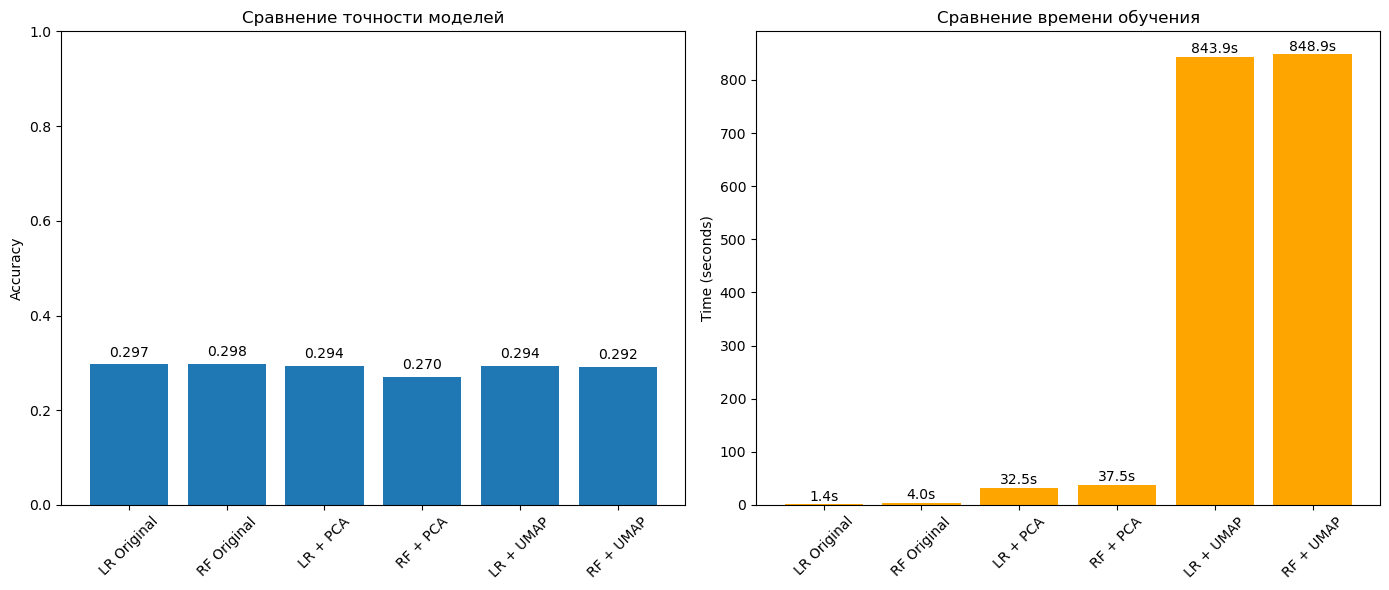

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
bars = ax1.bar(results['Model'], results['Test Accuracy'])
ax1.set_title('Сравнение точности моделей')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, results['Test Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom')

ax2 = axes[1]
bars = ax2.bar(results['Model'], results['Training Time (s)'], color='orange')
ax2.set_title('Сравнение времени обучения')
ax2.set_ylabel('Time (seconds)')
ax2.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, results['Training Time (s)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

- Слишком разреженные данные (~0.1% заполненности). Пользователи оценили мало книг, поэтому модели упираются в "потолок" ~30%.
- Все модели показывают очень близкиерезультаты.
- Методы снижения размерности справляются со своей задачей - при сокращении компонент до 200 (PCA) и до 5 (UMAP) мы сохранили качество моделей, правда время исполнения кода сильно увеличилось (вместо 1-4 сек на обучение потратили 23+ и 800+ сек)
1. ✅ ГЛАВНЫЙ УСПЕХ: СЖАТИЕ ДАННЫХ

   Исходные: 10,000 признаков → 0.2966 точности
   PCA:         200 признаков → 0.2942 точности (Сжатие в 50×!)
   UMAP:          5 признаков → 0.2940 точности (Сжатие в 2,000×!)
   
   ВЫВОД: Данные можно сжать в 2000 раз с потерей всего 0.0026 точности!

2. 📊 КАЧЕСТВО СОХРАНЕНО

   LR Original:  0.2966
   LR + UMAP:    0.2940 (99.1% от оригинала!)
   LR + PCA:     0.2942 (99.2% от оригинала!)
   
   ВЫВОД: Методы уменьшения размерности ЭФФЕКТИВНО сохраняют качество

3. ⏱️ ВРЕМЯ - ОДНОРАЗОВЫЕ ЗАТРАТЫ

   Время преобразования:
   - PCA:  27 секунд (один раз!)
   - UMAP: 840 секунд (один раз!)
   
   После преобразования:
   - Обучение на сжатых данных: ~3-5 секунд
   - Экономия памяти: 50-2000 раз
   
   ВЫВОД: Затраты окупаются при многократном использовании

4. 🎯 ПРАКТИЧЕСКАЯ ЦЕННОСТЬ

   ✅ Хранение данных: 2000× меньше памяти
   ✅ Быстрые эксперименты: модель обучается за секунды
   ✅ Визуализация: UMAP (5D) можно показать в 2D
   ✅ Интерпретация: меньше признаков = проще анализ

5. 🏆 ЛУЧШИЙ БАЛАНС

   Для хранения: UMAP (2000× сжатие, 99% качества)
   Для скорости: PCA (50× сжатие, 99% качества)
   Для точности: Исходные данные (100% качества)

6. 💡 ГЛАВНЫЙ ВЫВОД

   Задание показало, что:
   - Можно сжать данные в 2000 раз
   - При этом сохранить 99% качества
   - Затраты времени ОКУПАЮТСЯ при многократном использовании

## Visualizations (MNIST)

In [25]:
def load_mnist_images(filename):   
    with open(filename, 'rb') as f:
        # Читаем магическое число
        magic = int.from_bytes(f.read(4), 'big')
        n_images = int.from_bytes(f.read(4), 'big')
        n_rows = int.from_bytes(f.read(4), 'big')
        n_cols = int.from_bytes(f.read(4), 'big')
        
        data = np.frombuffer(f.read(), dtype=np.uint8)
        data = data.reshape(n_images, n_rows * n_cols)
        
    return data

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        magic = int.from_bytes(f.read(4), 'big')
        n_labels = int.from_bytes(f.read(4), 'big')
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        
    return labels

In [26]:
train_images_path = 'data/train-images.idx3-ubyte'
train_labels_path = 'data/train-labels.idx1-ubyte'
test_images_path = 'data/t10k-images.idx3-ubyte'
test_labels_path = 'data/t10k-labels.idx1-ubyte'

X_train = load_mnist_images(train_images_path)
y_train = load_mnist_labels(train_labels_path)

X_test = load_mnist_images(test_images_path)
y_test = load_mnist_labels(test_labels_path)

print(f"Train images: {X_train.shape}")
print(f"Train labels: {y_train.shape}")
print(f"Test images: {X_test.shape}")
print(f"Test labels: {y_test.shape}")

Train images: (60000, 784)
Train labels: (60000,)
Test images: (10000, 784)
Test labels: (10000,)


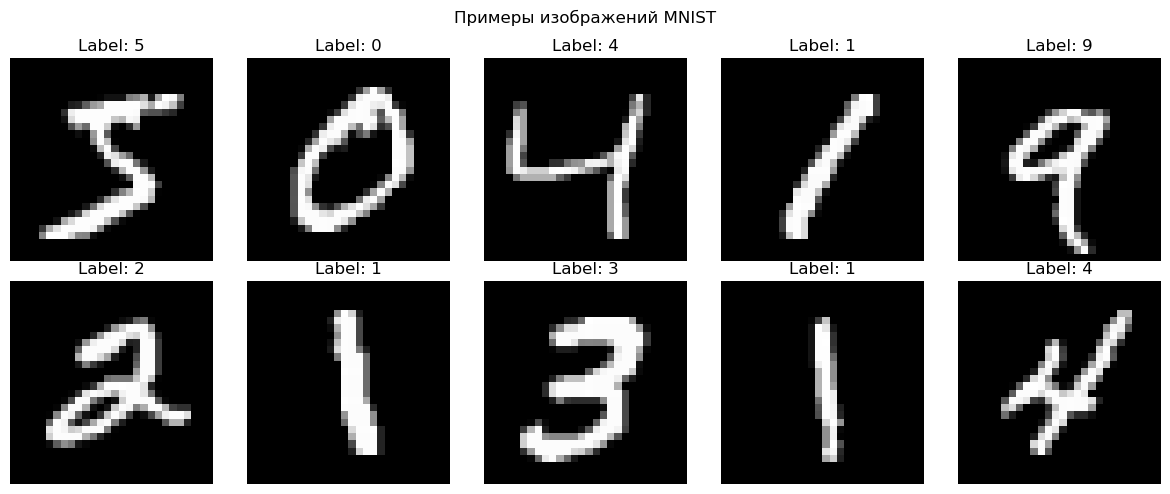

In [31]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Примеры изображений MNIST')
plt.tight_layout()
plt.show()

In [32]:
sample_size = 3000
np.random.seed(42)
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)

X_sample = X_train[indices]
y_sample = y_train[indices]

print(f"\nИспользуем {sample_size} изображений для визуализации")
print(f"Размерность: {X_sample.shape[1]} пикселей")


Используем 3000 изображений для визуализации
Размерность: 784 пикселей


In [33]:
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)
print(f"Данные нормализованы: mean={X_sample_scaled.mean():.2f}, std={X_sample_scaled.std():.2f}")
print(f"Подвыборка: {X_sample_scaled.shape}")

Данные нормализованы: mean=0.00, std=0.91
Подвыборка: (3000, 784)


In [ ]:
# pca = PCA(n_components=0.95, random_state=42)
# X_train_pca = pca.fit_transform(X_sample_scaled)

# print(f"Исходная размерность: {X_train.shape[1]}")
# print(f"После PCA: {X_train_pca.shape[1]}")
# print(f"Сохранено дисперсии: {pca.explained_variance_ratio_.sum():.2%}")

# print("\nСохранение модели...")

# os.makedirs('models', exist_ok=True)

# joblib.dump(pca, 'models/pca_model.joblib')
# joblib.dump(scaler, 'models/scaler.joblib')

# model_info = {
#     'n_components': pca.n_components_,
#     'explained_variance_ratio': pca.explained_variance_ratio_,
#     'mean': pca.mean_,
#     'components': pca.components_,
#     'original_shape': X_train.shape[1],
#     'compressed_shape': X_train_pca.shape[1]
# }

# np.save('models/model_info.npy', model_info)

# print("Модель сохранена в папку 'models/'")


ТЕСТОВЫЙ ПРИМЕР СЖАТИЯ И ВОССТАНОВЛЕНИЯ
Исходная цифра: 7
Исходный размер: (784,)
Сжатый размер: (1, 246)


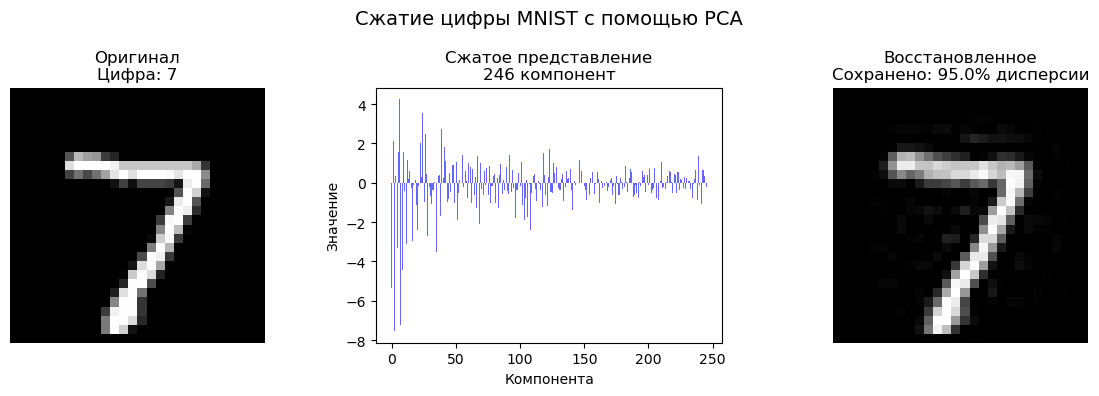

In [46]:
print("\n" + "="*60)
print("ТЕСТОВЫЙ ПРИМЕР СЖАТИЯ И ВОССТАНОВЛЕНИЯ")
print("="*60)

sample_idx = 0
original_digit = X_test[sample_idx]
true_label = y_test[sample_idx]

original_scaled = scaler.transform(original_digit.reshape(1, -1))
compressed = pca.transform(original_scaled)

reconstructed_scaled = pca.inverse_transform(compressed)
reconstructed = scaler.inverse_transform(reconstructed_scaled)
reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)

print(f"Исходная цифра: {true_label}")
print(f"Исходный размер: {original_digit.shape}")
print(f"Сжатый размер: {compressed.shape}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(original_digit.reshape(28, 28), cmap='gray')
axes[0].set_title(f'Оригинал\nЦифра: {true_label}')
axes[0].axis('off')

axes[1].bar(range(compressed.shape[1]), compressed.flatten(), color='blue', alpha=0.6)
axes[1].set_title(f'Сжатое представление\n{compressed.shape[1]} компонент')
axes[1].set_xlabel('Компонента')
axes[1].set_ylabel('Значение')

axes[2].imshow(reconstructed.reshape(28, 28), cmap='gray')
axes[2].set_title(f'Восстановленное\nСохранено: {pca.explained_variance_ratio_.sum():.1%} дисперсии')
axes[2].axis('off')

plt.suptitle('Сжатие цифры MNIST с помощью PCA', fontsize=14)
plt.tight_layout()
plt.show()

# ДЕМОНСТРАЦИЯ

In [45]:
def load_compression_model(model_path='models/'):
    import joblib
    import numpy as np
    import os
    
    pca = joblib.load(os.path.join(model_path, 'pca_model.joblib'))
    scaler = joblib.load(os.path.join(model_path, 'scaler.joblib'))
    model_info = np.load(os.path.join(model_path, 'model_info.npy'), allow_pickle=True).item()
    
    print(f"Модель загружена:")
    print(f"  - Исходная размерность: {model_info['original_shape']}")
    print(f"  - Сжатая размерность: {model_info['compressed_shape']}")
    print(f"  - Сохранено дисперсии: {model_info['explained_variance_ratio'].sum():.2%}")
    
    return pca, scaler, model_info

def compress_digit(digit, pca, scaler):
    if digit.shape == (28, 28):
        digit = digit.flatten()
    
    digit_scaled = scaler.transform(digit.reshape(1, -1))
    
    compressed = pca.transform(digit_scaled)
    
    reconstructed_scaled = pca.inverse_transform(compressed)
    reconstructed = scaler.inverse_transform(reconstructed_scaled)
    reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)
    
    return compressed, reconstructed

def compare_compression(digit, compressed, reconstructed):    
    mse = np.mean((digit - reconstructed.flatten()) ** 2)
    psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')
    
    print(f"\nРезультаты сжатия:")
    print(f"  - Исходный размер: {digit.size} элементов")
    print(f"  - Сжатый размер: {compressed.size} элементов")
    print(f"  - Коэффициент сжатия: {digit.size / compressed.size:.1f}x")
    print(f"  - MSE: {mse:.2f}")
    print(f"  - PSNR: {psnr:.2f} dB")
    
    return {'mse': mse, 'psnr': psnr, 'compression_ratio': digit.size / compressed.size}

if __name__ == "__main__":
    pca, scaler, model_info = load_compression_model()
        
    compressed, reconstructed = compress_digit(X_sample[0], pca, scaler)
    
    compare_compression(X_sample[0], compressed, reconstructed)
    
    print("\nПРОВЕРКА СОВПАДЕНИЯ ЗНАЧЕНИЙ")
    compressed1, reconstructed1 = compress_digit(test_digit, pca, scaler)
    print(f"\nСжатие #1:")
    print(f"  - compressed[:10]: {compressed1.flatten()[:10]}")
    print(f"  - reconstructed[:10]: {reconstructed1.flatten()[:10]}")
    
    compressed2, reconstructed2 = compress_digit(test_digit, pca, scaler)
    print(f"\nСжатие #2:")
    print(f"  - compressed[:10]: {compressed2.flatten()[:10]}")
    print(f"  - reconstructed[:10]: {reconstructed2.flatten()[:10]}")
    
    print(f"\nСравнение результатов:")
    print(f"  - Совпадение compressed: {np.allclose(compressed1, compressed2)}")
    print(f"  - Совпадение reconstructed: {np.allclose(reconstructed1, reconstructed2)}")
    
    if np.allclose(compressed1, compressed2) and np.allclose(reconstructed1, reconstructed2):
        print("  ✅ Значения полностью совпадают! Модель детерминирована.")
    else:
        print("  ⚠️ Значения отличаются. Проверьте модель.")

Модель загружена:
  - Исходная размерность: 784
  - Сжатая размерность: 246
  - Сохранено дисперсии: 95.04%

Результаты сжатия:
  - Исходный размер: 784 элементов
  - Сжатый размер: 246 элементов
  - Коэффициент сжатия: 3.2x
  - MSE: 23.67
  - PSNR: 34.39 dB

ПРОВЕРКА СОВПАДЕНИЯ ЗНАЧЕНИЙ

Сжатие #1:
  - compressed[:10]: [-3.51353354  0.75167563 -4.41620264  1.14443928  3.43127746 -1.0255495
 -0.0070969   1.46462559 -1.55022639  3.84264302]
  - reconstructed[:10]: [0 0 0 0 0 0 0 0 0 0]

Сжатие #2:
  - compressed[:10]: [-3.51353354  0.75167563 -4.41620264  1.14443928  3.43127746 -1.0255495
 -0.0070969   1.46462559 -1.55022639  3.84264302]
  - reconstructed[:10]: [0 0 0 0 0 0 0 0 0 0]

Сравнение результатов:
  - Совпадение compressed: True
  - Совпадение reconstructed: True
  ✅ Значения полностью совпадают! Модель детерминирована.


Загрузка MNIST...
Train: (60000, 784), Test: (10000, 784)

Используем 3000 изображений
Размерность: 784 -> 246

✅ Модель сохранена!

ДЕМОНСТРАЦИЯ
Цифра: 4


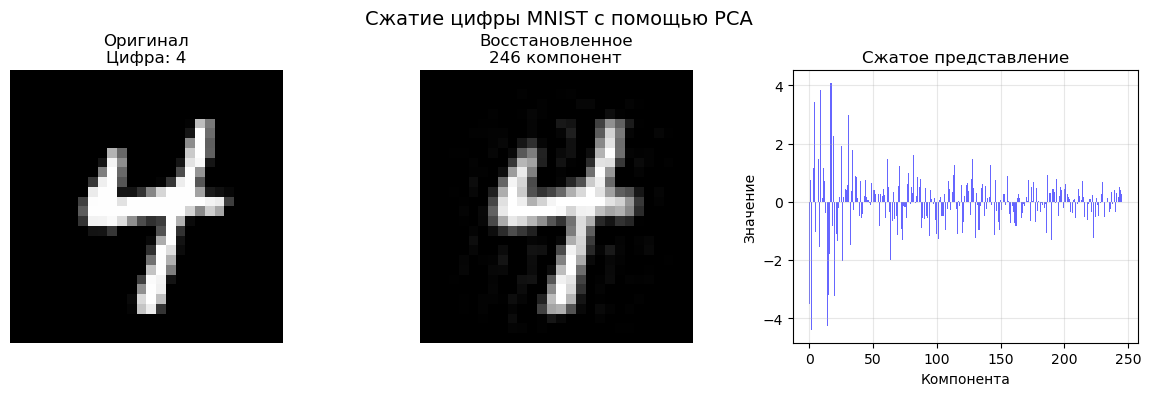

In [42]:
print("Загрузка MNIST...")
X_train = load_mnist_images('data/train-images.idx3-ubyte')
y_train = load_mnist_labels('data/train-labels.idx1-ubyte')
X_test = load_mnist_images('data/t10k-images.idx3-ubyte')
y_test = load_mnist_labels('data/t10k-labels.idx1-ubyte')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 3. Создание подвыборки
sample_size = 3000
np.random.seed(42)
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample = X_train[indices]
y_sample = y_train[indices]

print(f"\nИспользуем {sample_size} изображений")

# 4. Нормализация
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

# 5. PCA
pca = PCA(n_components=0.95, random_state=42)
X_sample_pca = pca.fit_transform(X_sample_scaled)
print(f"Размерность: {X_sample_scaled.shape[1]} -> {X_sample_pca.shape[1]}")

# 6. Сохранение модели
os.makedirs('models', exist_ok=True)
joblib.dump(pca, 'models/pca_model.joblib')
joblib.dump(scaler, 'models/scaler.joblib')

model_info = {
    'n_components': pca.n_components_,
    'explained_variance_ratio': pca.explained_variance_ratio_,
    'compressed_shape': X_sample_pca.shape[1],
    'sample_size': sample_size
}
np.save('models/model_info.npy', model_info)
print("\n✅ Модель сохранена!")

# 7. Демонстрация
print("\n" + "="*60)
print("ДЕМОНСТРАЦИЯ")
print("="*60)

# Берем случайную картинку
sample_idx = np.random.randint(0, len(X_test))
test_digit = X_test[sample_idx]
true_label = y_test[sample_idx]

print(f"Цифра: {true_label}")

# Сжатие
test_scaled = scaler.transform(test_digit.reshape(1, -1))
compressed = pca.transform(test_scaled)
reconstructed = pca.inverse_transform(compressed)
reconstructed = scaler.inverse_transform(reconstructed)
reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(test_digit.reshape(28, 28), cmap='gray')
axes[0].set_title(f'Оригинал\nЦифра: {true_label}')
axes[0].axis('off')

axes[1].imshow(reconstructed.reshape(28, 28), cmap='gray')
axes[1].set_title(f'Восстановленное\n{compressed.shape[1]} компонент')
axes[1].axis('off')

axes[2].bar(range(compressed.shape[1]), compressed.flatten(), color='blue', alpha=0.6)
axes[2].set_title('Сжатое представление')
axes[2].set_xlabel('Компонента')
axes[2].set_ylabel('Значение')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Сжатие цифры MNIST с помощью PCA', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
def reduce_dimensions(X, method='pca', n_components=2, **kwargs):
    print(f"  Применяем {method.upper()}...")
    start_time = time.time()
    
    if method == 'pca':
        reducer = PCA(n_components=n_components, random_state=42)
    elif method == 'svd':
        reducer = TruncatedSVD(n_components=n_components, random_state=42)
    elif method == 'randomized_svd':
        reducer = TruncatedSVD(n_components=n_components, random_state=42, 
                               algorithm='randomized', n_iter=5)
    elif method == 'tsne':
        reducer = TSNE(n_components=n_components, random_state=42, 
                       perplexity=kwargs.get('perplexity', 30),
                       n_iter=kwargs.get('n_iter', 1000))
    elif method == 'lle':
        reducer = LocallyLinearEmbedding(n_components=n_components, 
                                        random_state=42,
                                        n_neighbors=kwargs.get('n_neighbors', 30))
    elif method == 'umap':
        reducer = umap.UMAP(n_components=n_components, random_state=42,
                           n_neighbors=kwargs.get('n_neighbors', 15),
                           min_dist=kwargs.get('min_dist', 0.1))
    else:
        raise ValueError(f"Неизвестный метод: {method}")
    
    X_reduced = reducer.fit_transform(X)
    elapsed_time = time.time() - start_time
    print(f"    Время: {elapsed_time:.2f}с")
    
    return X_reduced, elapsed_time

In [20]:
methods = ['pca', 'svd', 'randomized_svd', 'tsne', 'lle', 'umap']
results = {}
reduced_data = {}
for method in methods:
    print(f"\n--- {method.upper()} ---")
    kwargs = {}
    if method == 'tsne':
        kwargs = {'perplexity': 30, 'n_iter': 1000}
    elif method == 'lle':
        kwargs = {'n_neighbors': 30}
    elif method == 'umap':
        kwargs = {'n_neighbors': 15, 'min_dist': 0.1}
    
    X_reduced, elapsed_time = reduce_dimensions(
        X_sample_scaled, method=method, n_components=2, **kwargs
    )
    
    reduced_data[method] = X_reduced
    results[method] = {'time': elapsed_time}


--- PCA ---
  Применяем PCA...
    Время: 0.19с

--- SVD ---
  Применяем SVD...
    Время: 0.10с

--- RANDOMIZED_SVD ---
  Применяем RANDOMIZED_SVD...
    Время: 0.07с

--- TSNE ---
  Применяем TSNE...


/home/andrei/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


    Время: 10.86с

--- LLE ---
  Применяем LLE...
    Время: 3.53с

--- UMAP ---
  Применяем UMAP...


/home/andrei/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


    Время: 26.84с


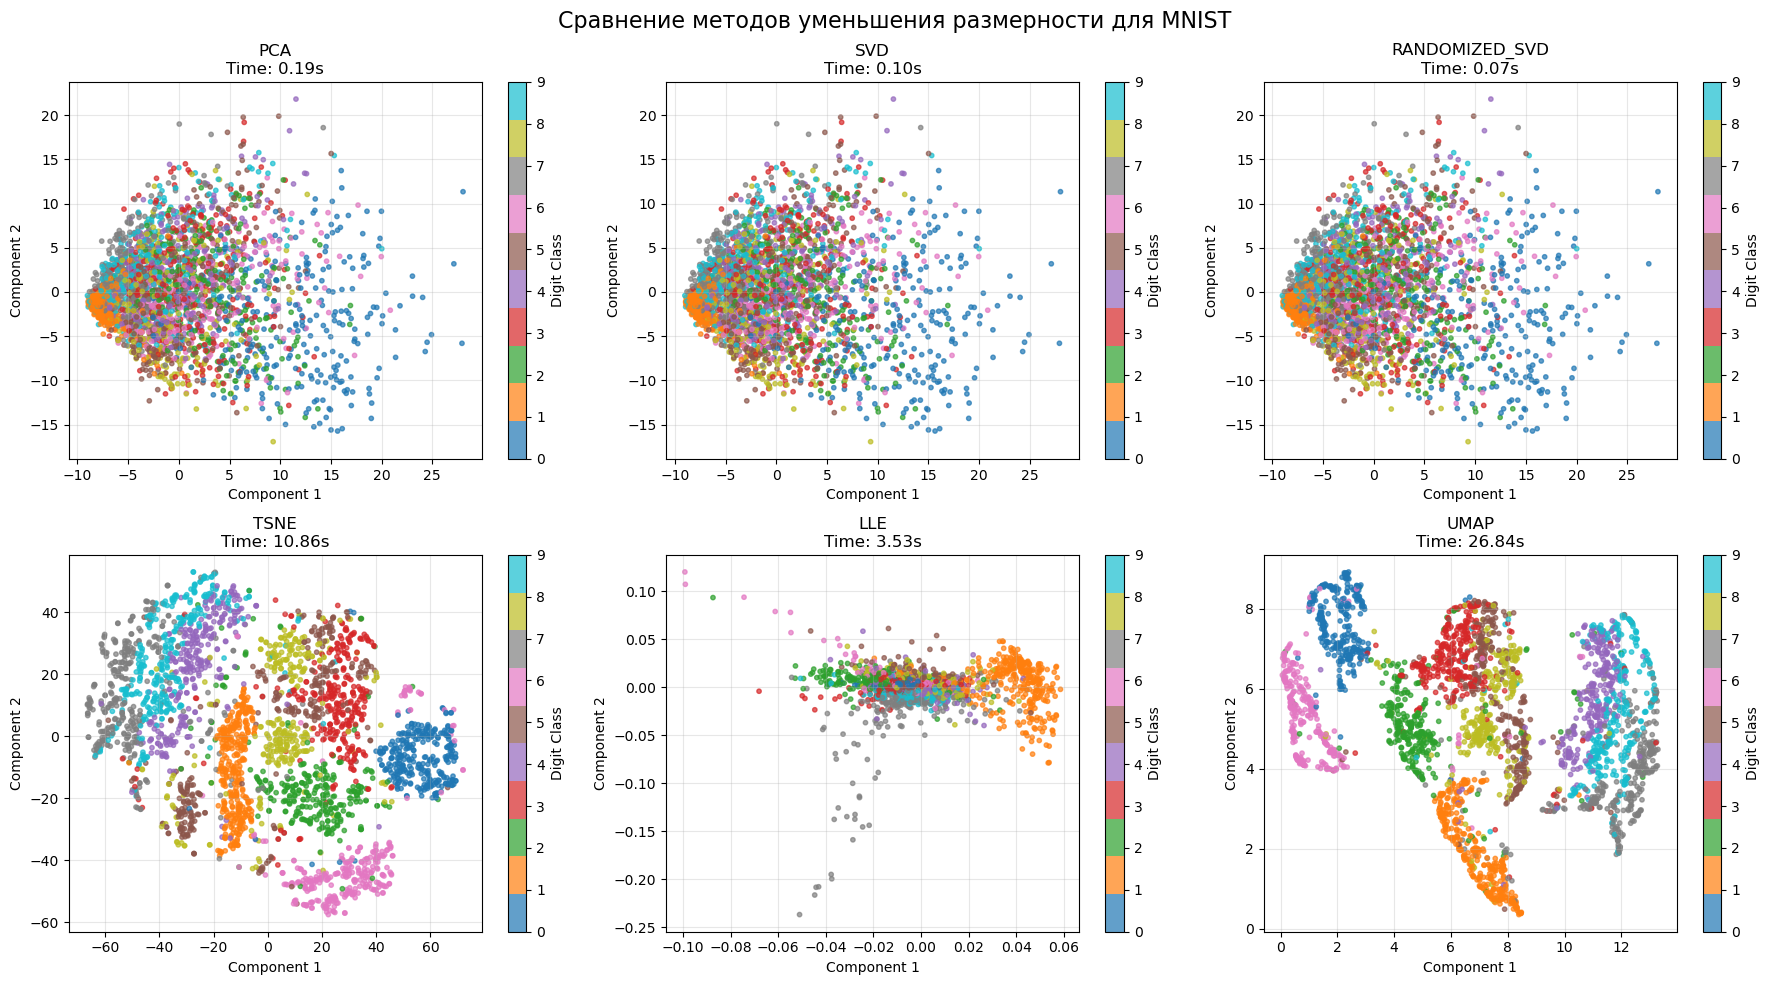

In [21]:
def plot_embeddings(X_embedded, y, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    scatter = ax.scatter(X_embedded[:, 0], X_embedded[:, 1], 
                        c=y, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Digit Class')
    return ax

n_methods = len(methods)
n_cols = 3
n_rows = (n_methods + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for idx, method in enumerate(methods):
    X_embedded = reduced_data[method]
    plot_embeddings(X_embedded, y_sample, 
                   f'{method.upper()}\nTime: {results[method]["time"]:.2f}s', 
                   ax=axes[idx])

for idx in range(len(methods), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Сравнение методов уменьшения размерности для MNIST', fontsize=16)
plt.tight_layout()
plt.show()

In [27]:
def calculate_metrics(X_embedded, y_true):
    # Silhouette Score (чем выше, тем лучше)
    try:
        silhouette = silhouette_score(X_embedded, y_true, metric='euclidean')
    except:
        silhouette = 0
    
    # Calinski-Harabasz Index (чем выше, тем лучше)
    try:
        calinski = calinski_harabasz_score(X_embedded, y_true)
    except:
        calinski = 0
    
    # Davies-Bouldin Index (чем меньше, тем лучше)
    try:
        davies = davies_bouldin_score(X_embedded, y_true)
    except:
        davies = 0
    
    # Внутрикластерная дисперсия (чем меньше, тем лучше)
    unique_labels = np.unique(y_true)
    within_cluster_var = 0
    for label in unique_labels:
        cluster_points = X_embedded[y_true == label]
        if len(cluster_points) > 1:
            within_cluster_var += np.var(cluster_points, axis=0).mean()
    within_cluster_var /= len(unique_labels)
    
    # Межкластерная дисперсия (чем больше, тем лучше)
    global_mean = np.mean(X_embedded, axis=0)
    between_cluster_var = 0
    for label in unique_labels:
        cluster_mean = np.mean(X_embedded[y_true == label], axis=0)
        between_cluster_var += np.linalg.norm(cluster_mean - global_mean)**2
    between_cluster_var /= len(unique_labels)
    
    # Соотношение между/внутри (чем больше, тем лучше)
    ratio = between_cluster_var / (within_cluster_var + 1e-10)
    
    return {
        'silhouette': silhouette,
        'calinski_harabasz': calinski,
        'davies_bouldin': davies,
        'within_cluster_var': within_cluster_var,
        'between_cluster_var': between_cluster_var,
        'ratio': ratio
    }

In [28]:
metrics_results = {}

for method in methods:
    X_embedded = reduced_data[method]
    metrics = calculate_metrics(X_embedded, y_sample)
    metrics_results[method] = metrics
    
    print(f"\n{method.upper()}:")
    print(f"  Silhouette Score: {metrics['silhouette']:.4f}")
    print(f"  Calinski-Harabasz: {metrics['calinski_harabasz']:.2f}")
    print(f"  Davies-Bouldin: {metrics['davies_bouldin']:.4f}")
    print(f"  Between/Within Ratio: {metrics['ratio']:.2f}")


PCA:
  Silhouette Score: -0.0829
  Calinski-Harabasz: 184.43
  Davies-Bouldin: 6.9216
  Between/Within Ratio: 1.08

SVD:
  Silhouette Score: -0.0829
  Calinski-Harabasz: 184.43
  Davies-Bouldin: 6.9232
  Between/Within Ratio: 1.08

RANDOMIZED_SVD:
  Silhouette Score: -0.0829
  Calinski-Harabasz: 184.43
  Davies-Bouldin: 6.9232
  Between/Within Ratio: 1.08

TSNE:
  Silhouette Score: 0.1256
  Calinski-Harabasz: 830.70
  Davies-Bouldin: 3.4851
  Between/Within Ratio: 4.93

LLE:
  Silhouette Score: -0.1213
  Calinski-Harabasz: 211.16
  Davies-Bouldin: 5.0410
  Between/Within Ratio: 1.24

UMAP:
  Silhouette Score: 0.2052
  Calinski-Harabasz: 1677.59
  Davies-Bouldin: 3.0806
  Between/Within Ratio: 9.99


In [29]:
comparison_df = pd.DataFrame({
    method: {
        'Silhouette': metrics_results[method]['silhouette'],
        'Calinski-Harabasz': metrics_results[method]['calinski_harabasz'],
        'Davies-Bouldin': metrics_results[method]['davies_bouldin'],
        'Ratio': metrics_results[method]['ratio'],
        'Time (s)': results[method]['time']
    }
    for method in methods
}).T

print("\n" + "="*60)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА")
print("="*60)
print(comparison_df.round(4).to_string())


СРАВНИТЕЛЬНАЯ ТАБЛИЦА
                Silhouette  Calinski-Harabasz  Davies-Bouldin   Ratio  Time (s)
pca                -0.0829           184.4341          6.9216  1.0833    0.1932
svd                -0.0829           184.4334          6.9232  1.0833    0.0965
randomized_svd     -0.0829           184.4334          6.9232  1.0833    0.0676
tsne                0.1256           830.7050          3.4851  4.9327   10.8593
lle                -0.1213           211.1621          5.0410  1.2412    3.5331
umap                0.2052          1677.5859          3.0806  9.9918   26.8409


In [30]:
best_silhouette = max(metrics_results, key=lambda x: metrics_results[x]['silhouette'])
best_time = min(results, key=lambda x: results[x]['time'])

print(f"""
1. ЛУЧШИЙ ПО SILHOUETTE: {best_silhouette.upper()}
   - Silhouette Score: {metrics_results[best_silhouette]['silhouette']:.4f}

2. САМЫЙ БЫСТРЫЙ: {best_time.upper()}
   - Время: {results[best_time]['time']:.2f}с

3. РЕКОМЕНДАЦИИ:
   - Для визуализации: t-SNE или UMAP
   - Для быстрого анализа: PCA или SVD
   - Для баланса: LLE
""")


1. ЛУЧШИЙ ПО SILHOUETTE: UMAP
   - Silhouette Score: 0.2052

2. САМЫЙ БЫСТРЫЙ: RANDOMIZED_SVD
   - Время: 0.07с

3. РЕКОМЕНДАЦИИ:
   - Для визуализации: t-SNE или UMAP
   - Для быстрого анализа: PCA или SVD
   - Для баланса: LLE



## Image compression using SVD

In [10]:
def load_grayscale_image(path):
    img = Image.open(path).convert('L')  # 'L' = grayscale
    img_array = np.array(img, dtype=np.float64)
    return img_array

image_paths = ['data/1.jpg', 'data/2.jpeg', 'data/3.jpg']
images = []
image_names = []

for path in image_paths:
    if os.path.exists(path):
        img = load_grayscale_image(path)
        images.append(img)
        image_names.append(os.path.basename(path))
        print(f"Загружено: {path}, размер: {img.shape}")
    else:
        print(f"Файл не найден: {path}")

Загружено: data/1.jpg, размер: (612, 408)
Загружено: data/2.jpeg, размер: (1024, 1024)
Загружено: data/3.jpg, размер: (493, 740)


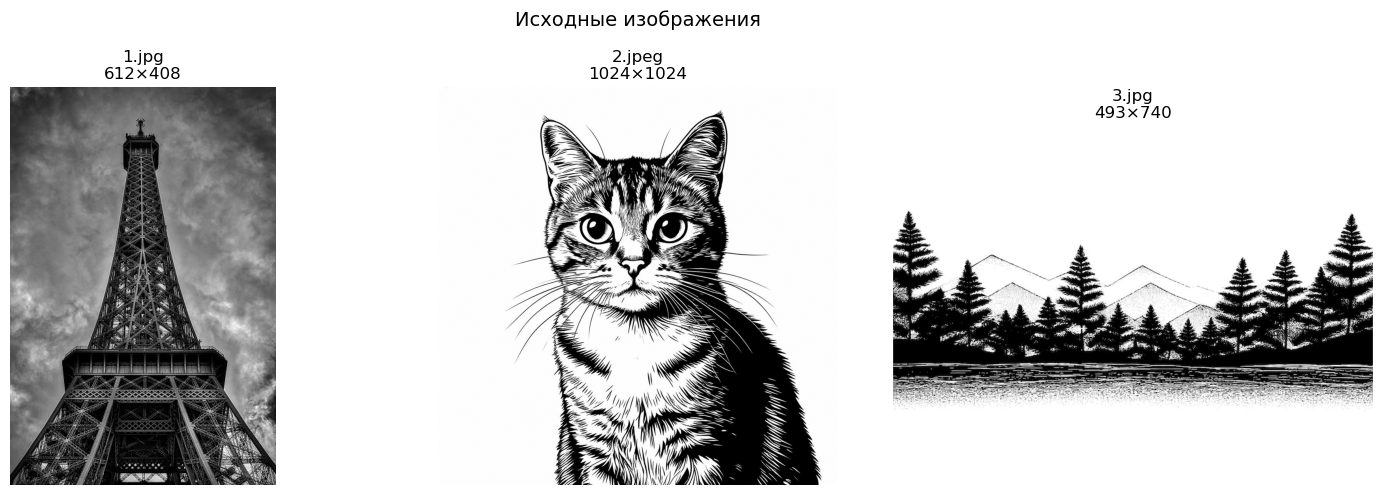

In [11]:
fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

for idx, (img, name) in enumerate(zip(images, image_names)):
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{name}\n{img.shape[0]}×{img.shape[1]}')
    axes[idx].axis('off')

plt.suptitle('Исходные изображения', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
def svd_compress_image(image, rank):
    U, S, Vt = np.linalg.svd(image, full_matrices=False)
    
    U_k = U[:, :rank]
    S_k = np.diag(S[:rank])
    Vt_k = Vt[:rank, :]
    
    compressed = U_k @ S_k @ Vt_k
    
    compressed = np.clip(compressed, 0, 255)
    
    return compressed, S

img = images[0]
m, n = img.shape
print(f"Размер изображения: {m} × {n}")
print(f"Количество пикселей: {m * n}")

U, S, Vt = np.linalg.svd(img, full_matrices=False)

print(f"Размер U: {U.shape}")
print(f"Размер S: {S.shape} (сингулярных значений: {len(S)})")
print(f"Размер Vt: {Vt.shape}")

for rank in [10, 50, 100, 200]:
    pixels = rank * (m + n + 1)
    compression_ratio = (m * n) / pixels
    print(f"Ранг {rank}: {pixels} элементов, сжатие в {compression_ratio:.1f} раз")

print(f"\nПервые 10 сингулярных значений:")
for i, s in enumerate(S[:10]):
    print(f"  σ_{i+1} = {s:.2f}")

Размер изображения: 612 × 408
Количество пикселей: 249696
Размер U: (612, 408)
Размер S: (408,) (сингулярных значений: 408)
Размер Vt: (408, 408)
Ранг 10: 10210 элементов, сжатие в 24.5 раз
Ранг 50: 51050 элементов, сжатие в 4.9 раз
Ранг 100: 102100 элементов, сжатие в 2.4 раз
Ранг 200: 204200 элементов, сжатие в 1.2 раз

Первые 10 сингулярных значений:
  σ_1 = 50275.10
  σ_2 = 10813.16
  σ_3 = 7062.10
  σ_4 = 6023.77
  σ_5 = 5037.84
  σ_6 = 3880.37
  σ_7 = 3853.86
  σ_8 = 3228.18
  σ_9 = 3139.94
  σ_10 = 2982.20


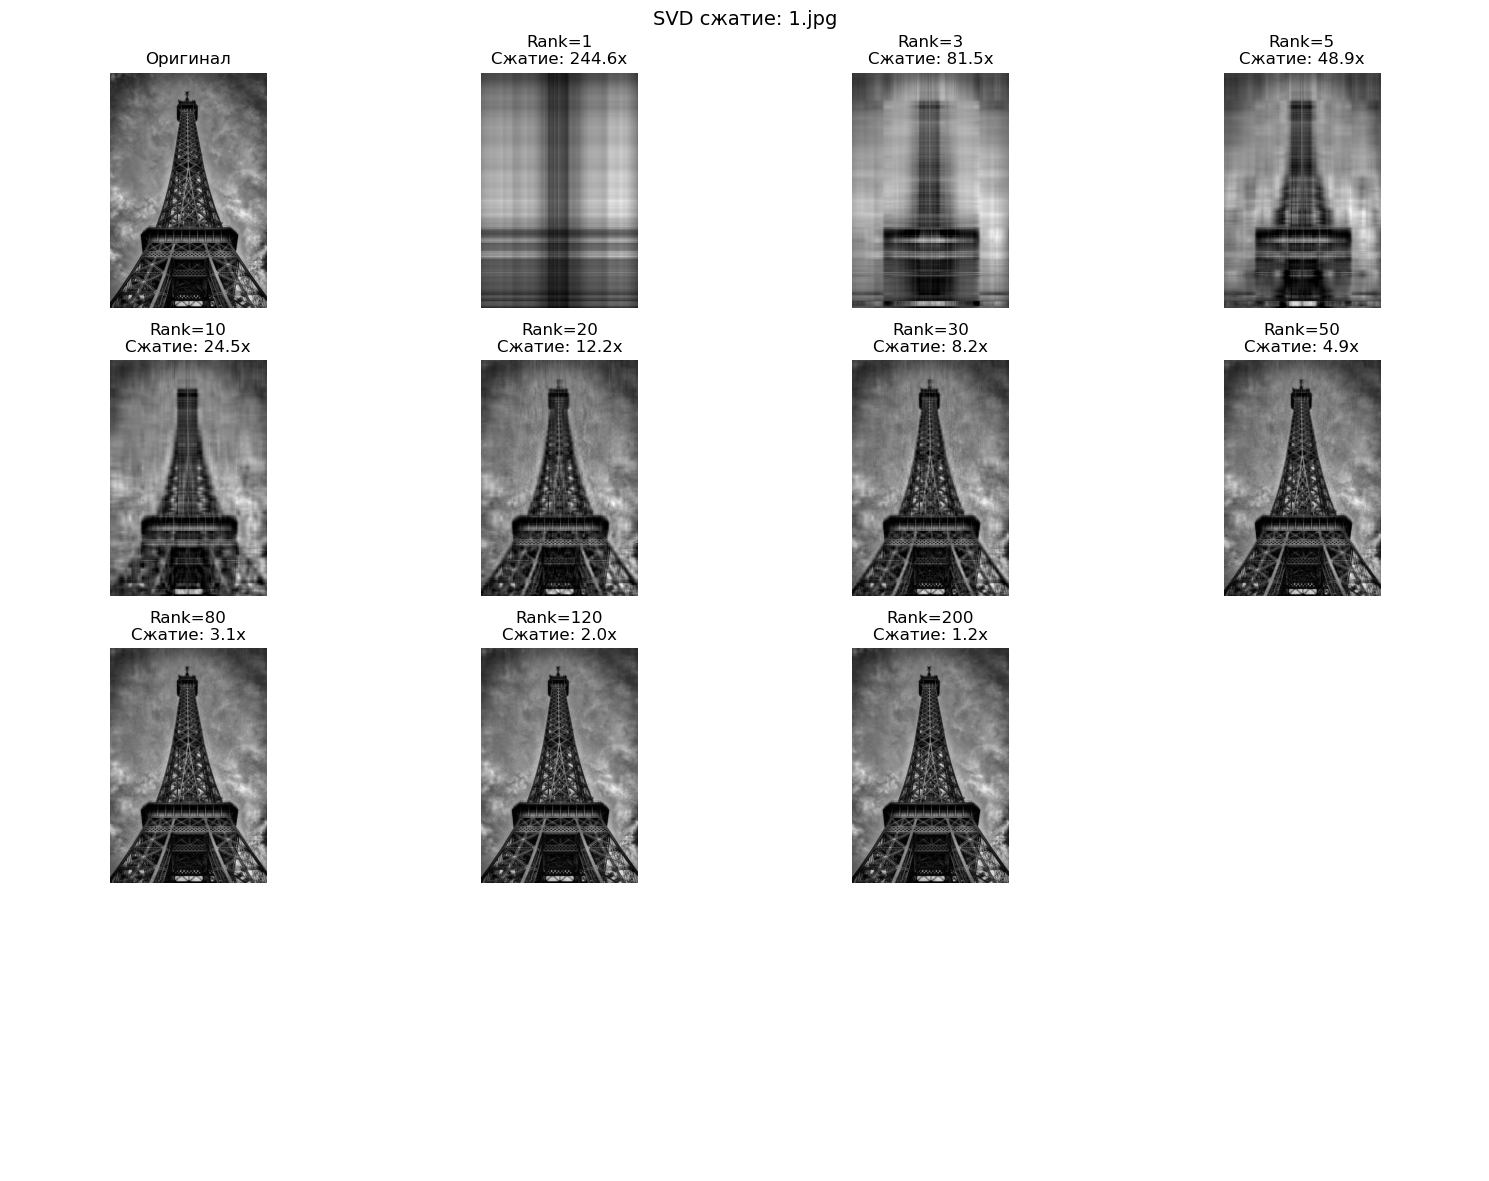

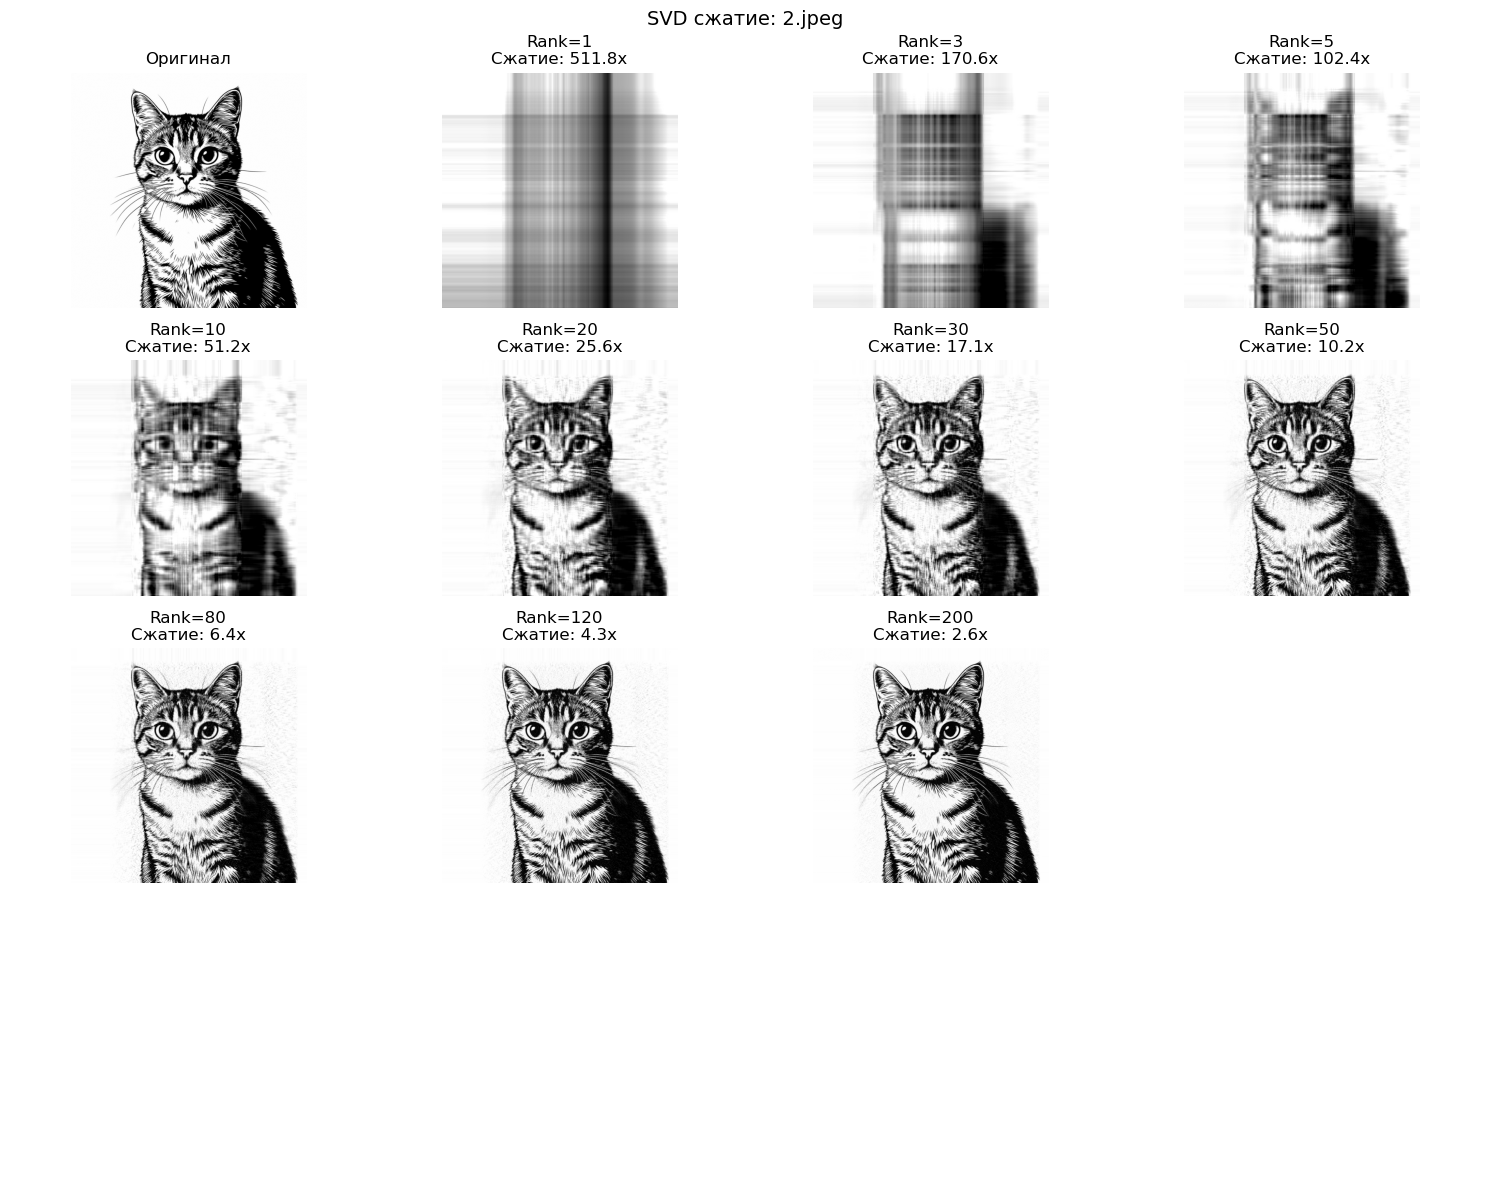

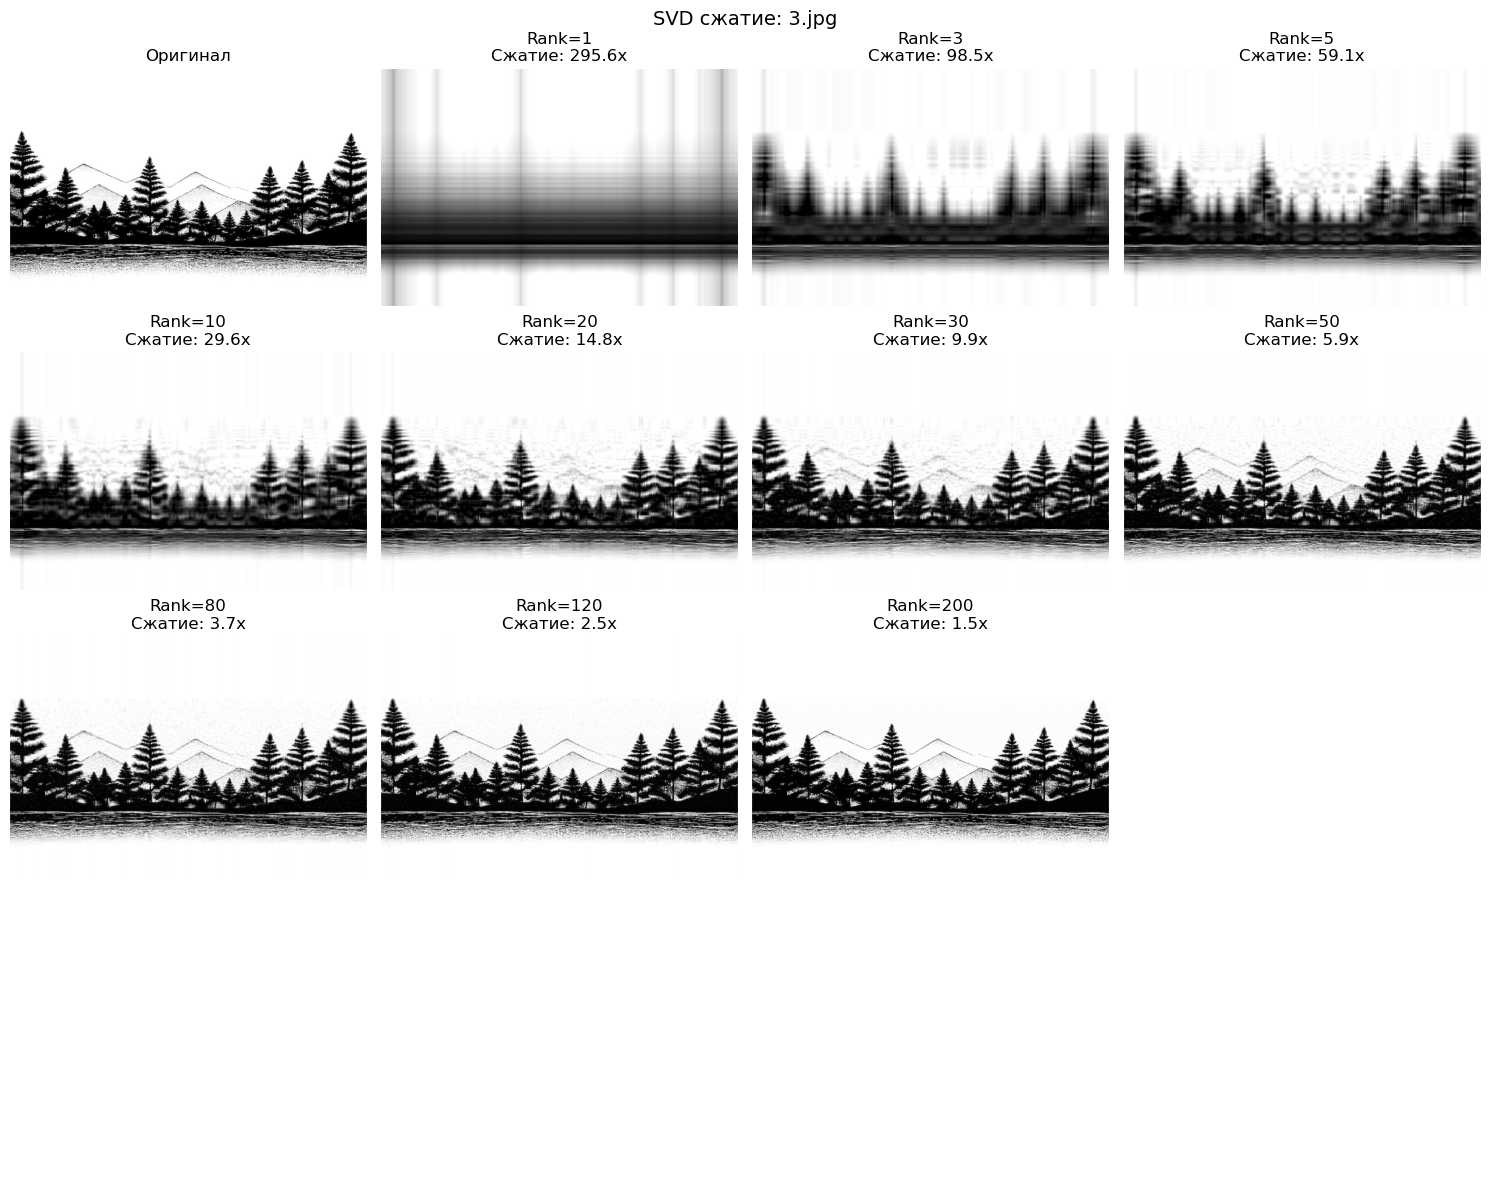

In [15]:
def plot_svd_ranks(image, ranks, title):
    n_ranks = len(ranks)
    cols = 4
    rows = (n_ranks + cols - 1) // cols + 1  # +1 для оригинала
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    axes = axes.flatten()
    
    ax = axes[0]
    ax.imshow(image, cmap='gray')
    ax.set_title('Оригинал')
    ax.axis('off')
    
    for idx, rank in enumerate(ranks):
        compressed, _ = svd_compress_image(image, rank)
        ax = axes[idx + 1]
        ax.imshow(compressed, cmap='gray')
        compression_ratio = image.size / (rank * (image.shape[0] + image.shape[1] + 1))
        ax.set_title(f'Rank={rank}\nСжатие: {compression_ratio:.1f}x')
        ax.axis('off')
    
    for idx in range(n_ranks + 1, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

ranks = [1, 3, 5, 10, 20, 30, 50, 80, 120, 200]

plot_svd_ranks(images[0], ranks, f'SVD сжатие: {image_names[0]}')

for img, name in zip(images[1:], image_names[1:]):
    plot_svd_ranks(img, ranks, f'SVD сжатие: {name}')


--- Спектр для 1.jpg ---


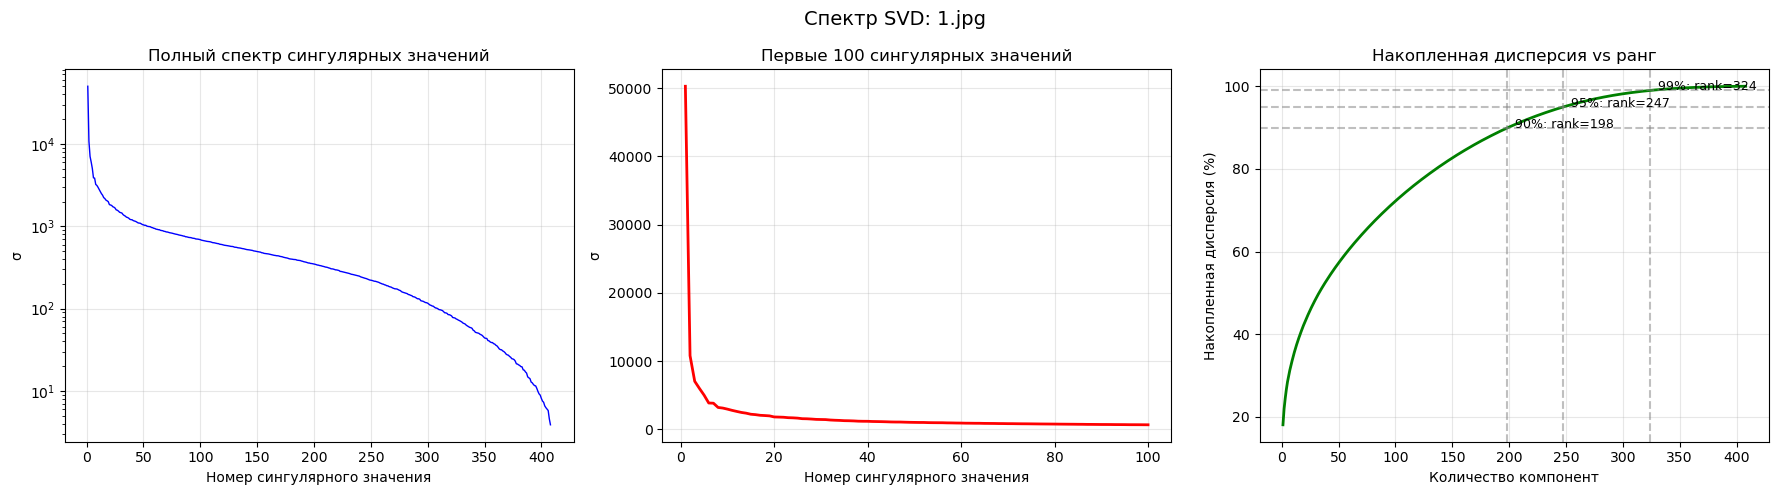

Для 90% дисперсии требуется rank = 199
Для 95% дисперсии требуется rank = 248
Для 99% дисперсии требуется rank = 325

--- Спектр для 2.jpeg ---


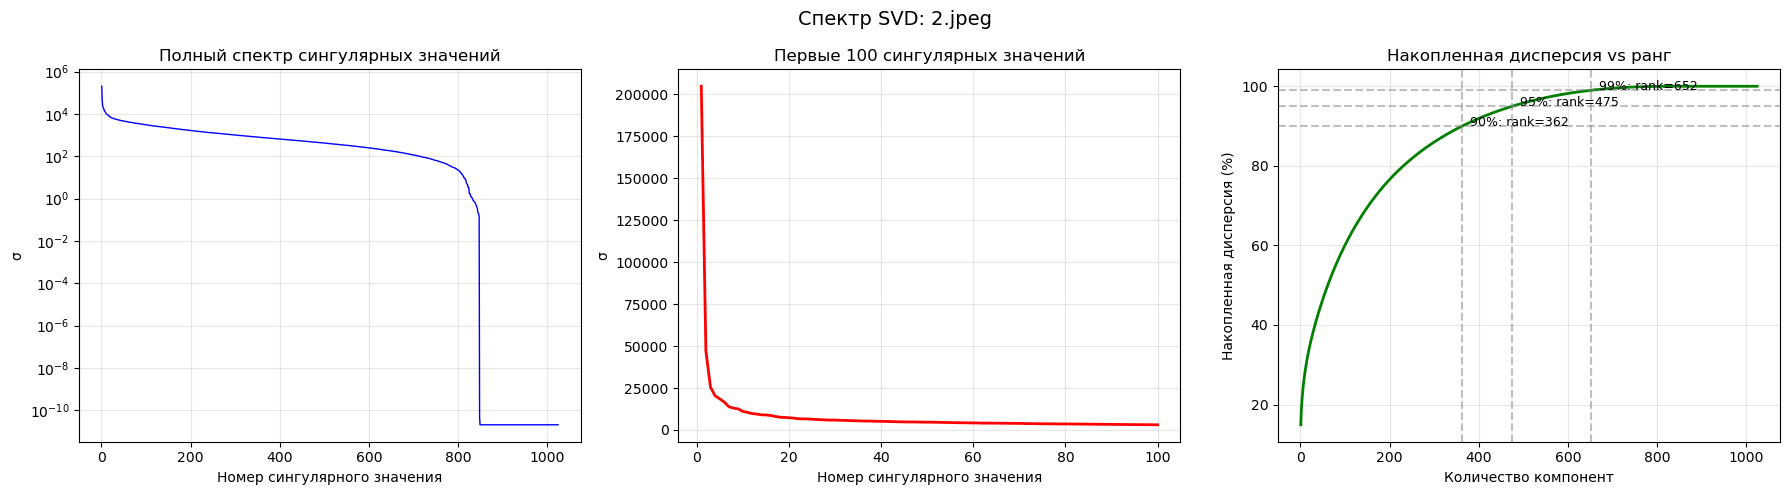

Для 90% дисперсии требуется rank = 363
Для 95% дисперсии требуется rank = 476
Для 99% дисперсии требуется rank = 653

--- Спектр для 3.jpg ---


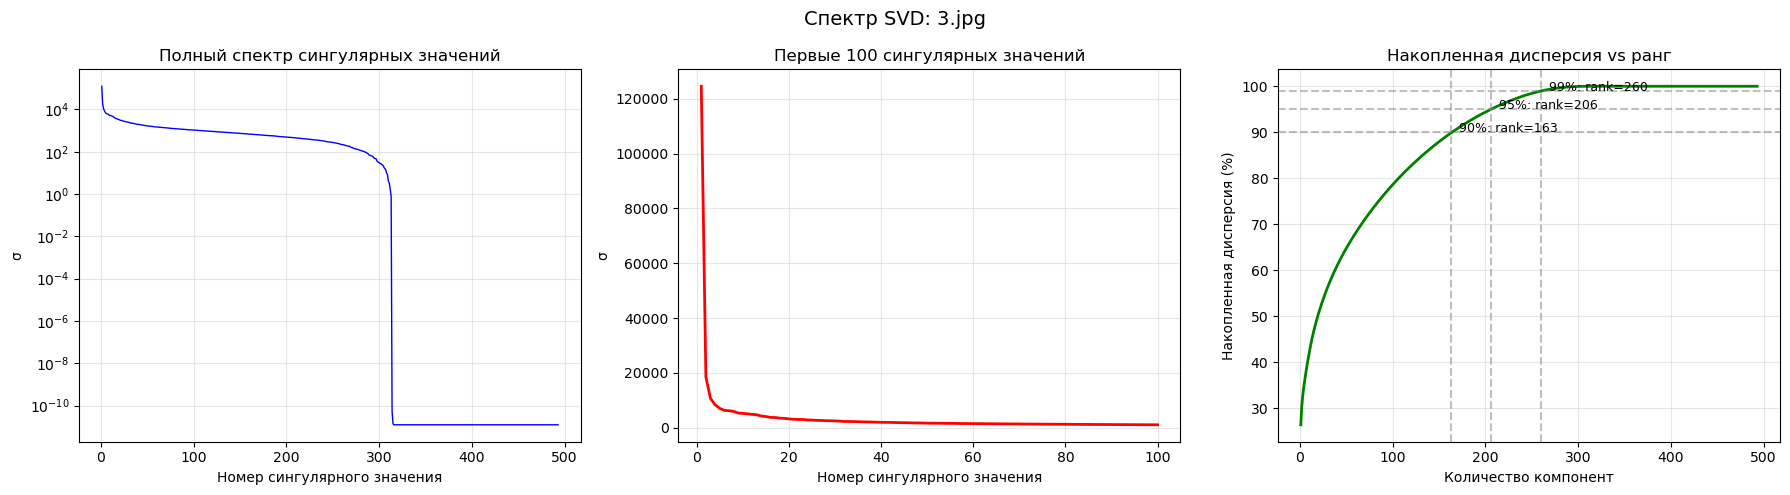

Для 90% дисперсии требуется rank = 164
Для 95% дисперсии требуется rank = 207
Для 99% дисперсии требуется rank = 261


In [16]:
def plot_singular_spectrum(image, title):
    _, S, _ = np.linalg.svd(image, full_matrices=False)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    ax = axes[0]
    ax.plot(range(1, len(S)+1), S, 'b-', linewidth=1)
    ax.set_xlabel('Номер сингулярного значения')
    ax.set_ylabel('σ')
    ax.set_title('Полный спектр сингулярных значений')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Первые 100 значений
    ax = axes[1]
    n_show = min(100, len(S))
    ax.plot(range(1, n_show+1), S[:n_show], 'r-', linewidth=2)
    ax.set_xlabel('Номер сингулярного значения')
    ax.set_ylabel('σ')
    ax.set_title(f'Первые {n_show} сингулярных значений')
    ax.grid(True, alpha=0.3)
    
    # Накопленная сумма
    ax = axes[2]
    cumsum = np.cumsum(S) / np.sum(S) * 100
    ax.plot(range(1, len(cumsum)+1), cumsum, 'g-', linewidth=2)
    
    for level in [90, 95, 99]:
        idx = np.argmax(cumsum >= level)
        ax.axhline(y=level, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(x=idx, color='gray', linestyle='--', alpha=0.5)
        ax.text(idx, level, f'  {level}%: rank={idx}', fontsize=9)
    
    ax.set_xlabel('Количество компонент')
    ax.set_ylabel('Накопленная дисперсия (%)')
    ax.set_title('Накопленная дисперсия vs ранг')
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return S

spectra = {}
for img, name in zip(images, image_names):
    print(f"\n--- Спектр для {name} ---")
    S = plot_singular_spectrum(img, f'Спектр SVD: {name}')
    spectra[name] = S
    
    cumsum = np.cumsum(S) / np.sum(S)
    for level in [90, 95, 99]:
        rank = np.argmax(cumsum >= level/100) + 1
        print(f"Для {level}% дисперсии требуется rank = {rank}")


ОБЪЯСНЕННАЯ ДИСПЕРСИЯ

--- 1.jpg ---


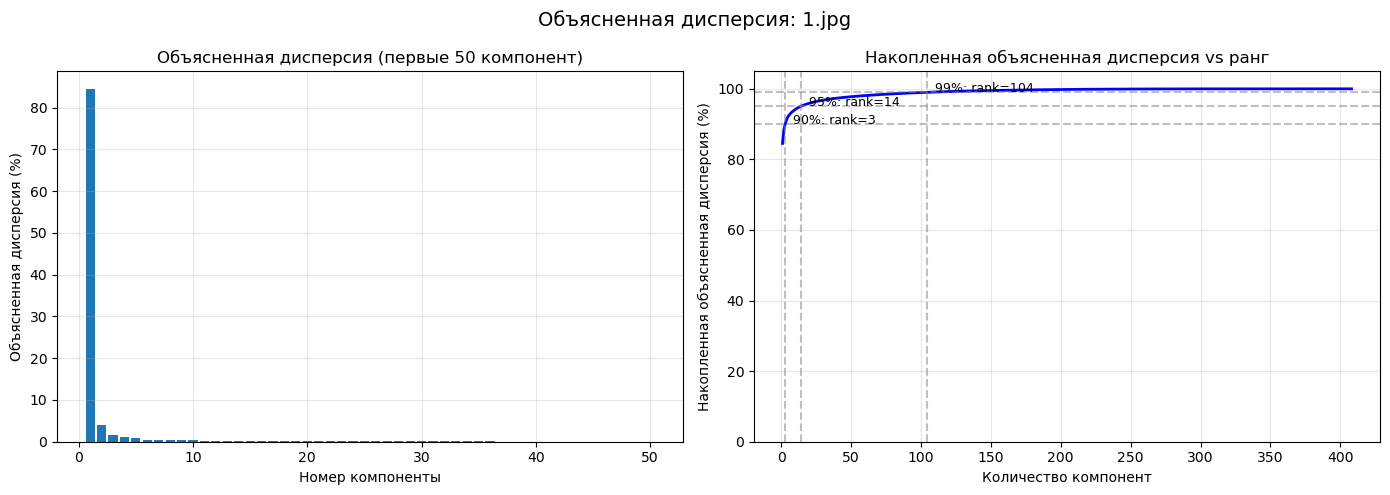

Общая дисперсия: 2990424839.00
Первая компонента объясняет: 84.52%
Первые 10 компонент объясняют: 94.14%
Первые 50 компонент объясняют: 97.76%

--- 2.jpeg ---


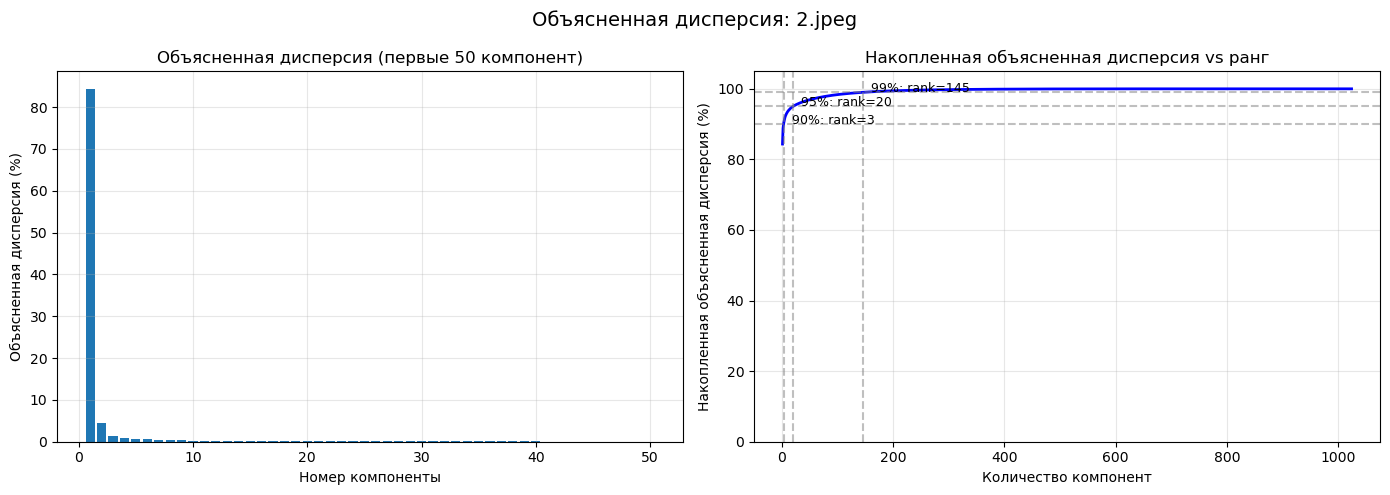

Общая дисперсия: 49709983381.00
Первая компонента объясняет: 84.35%
Первые 10 компонент объясняют: 93.48%
Первые 50 компонент объясняют: 96.92%

--- 3.jpg ---


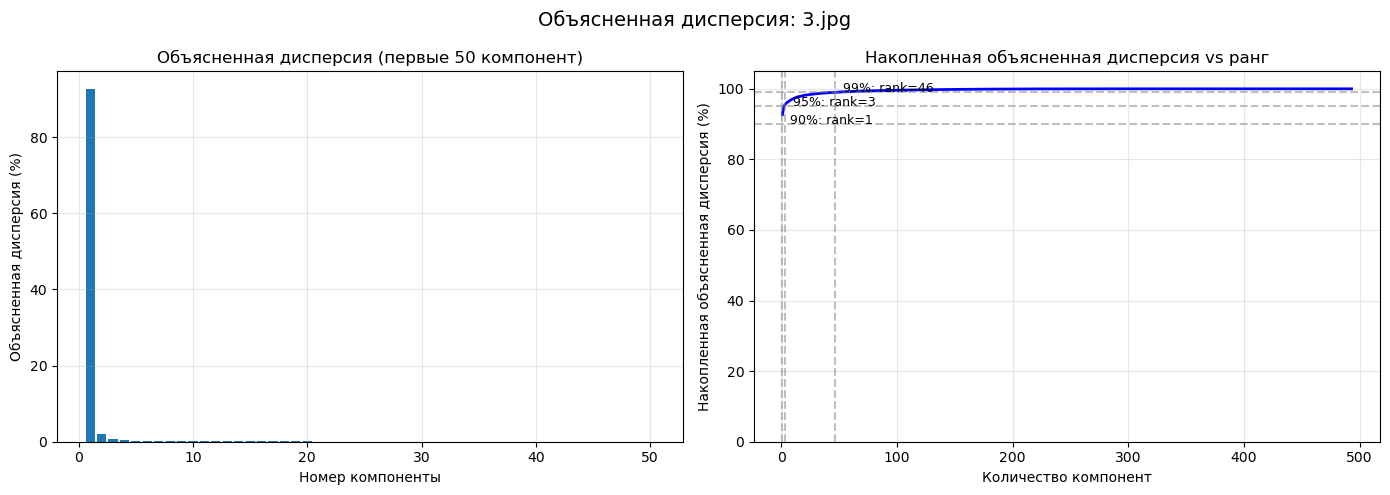

Общая дисперсия: 16734705866.00
Первая компонента объясняет: 92.70%
Первые 10 компонент объясняют: 97.15%
Первые 50 компонент объясняют: 99.08%


In [7]:
def plot_explained_variance(image, title):
    _, S, _ = np.linalg.svd(image, full_matrices=False)
    
    total_variance = np.sum(S**2)
    explained_variance = (S**2) / total_variance * 100
    cumulative_variance = np.cumsum(explained_variance)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    n_show = min(50, len(explained_variance))
    ax.bar(range(1, n_show+1), explained_variance[:n_show])
    ax.set_xlabel('Номер компоненты')
    ax.set_ylabel('Объясненная дисперсия (%)')
    ax.set_title(f'Объясненная дисперсия (первые {n_show} компонент)')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-', linewidth=2)
    
    for level in [90, 95, 99]:
        idx = np.argmax(cumulative_variance >= level) + 1
        ax.axhline(y=level, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(x=idx, color='gray', linestyle='--', alpha=0.5)
        ax.text(idx, level, f'  {level}%: rank={idx}', fontsize=9)
    
    ax.set_xlabel('Количество компонент')
    ax.set_ylabel('Накопленная объясненная дисперсия (%)')
    ax.set_title('Накопленная объясненная дисперсия vs ранг')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 105)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return explained_variance, cumulative_variance

print("\n" + "="*60)
print("ОБЪЯСНЕННАЯ ДИСПЕРСИЯ")
print("="*60)

variance_results = {}
for img, name in zip(images, image_names):
    print(f"\n--- {name} ---")
    exp_var, cum_var = plot_explained_variance(img, f'Объясненная дисперсия: {name}')
    variance_results[name] = {
        'explained': exp_var,
        'cumulative': cum_var
    }
    
    print(f"Общая дисперсия: {np.sum(img**2):.2f}")
    print(f"Первая компонента объясняет: {exp_var[0]:.2f}%")
    print(f"Первые 10 компонент объясняют: {cum_var[9]:.2f}%")
    print(f"Первые 50 компонент объясняют: {cum_var[min(49, len(cum_var)-1)]:.2f}%")


СРАВНЕНИЕ ВСЕХ ИЗОБРАЖЕНИЙ


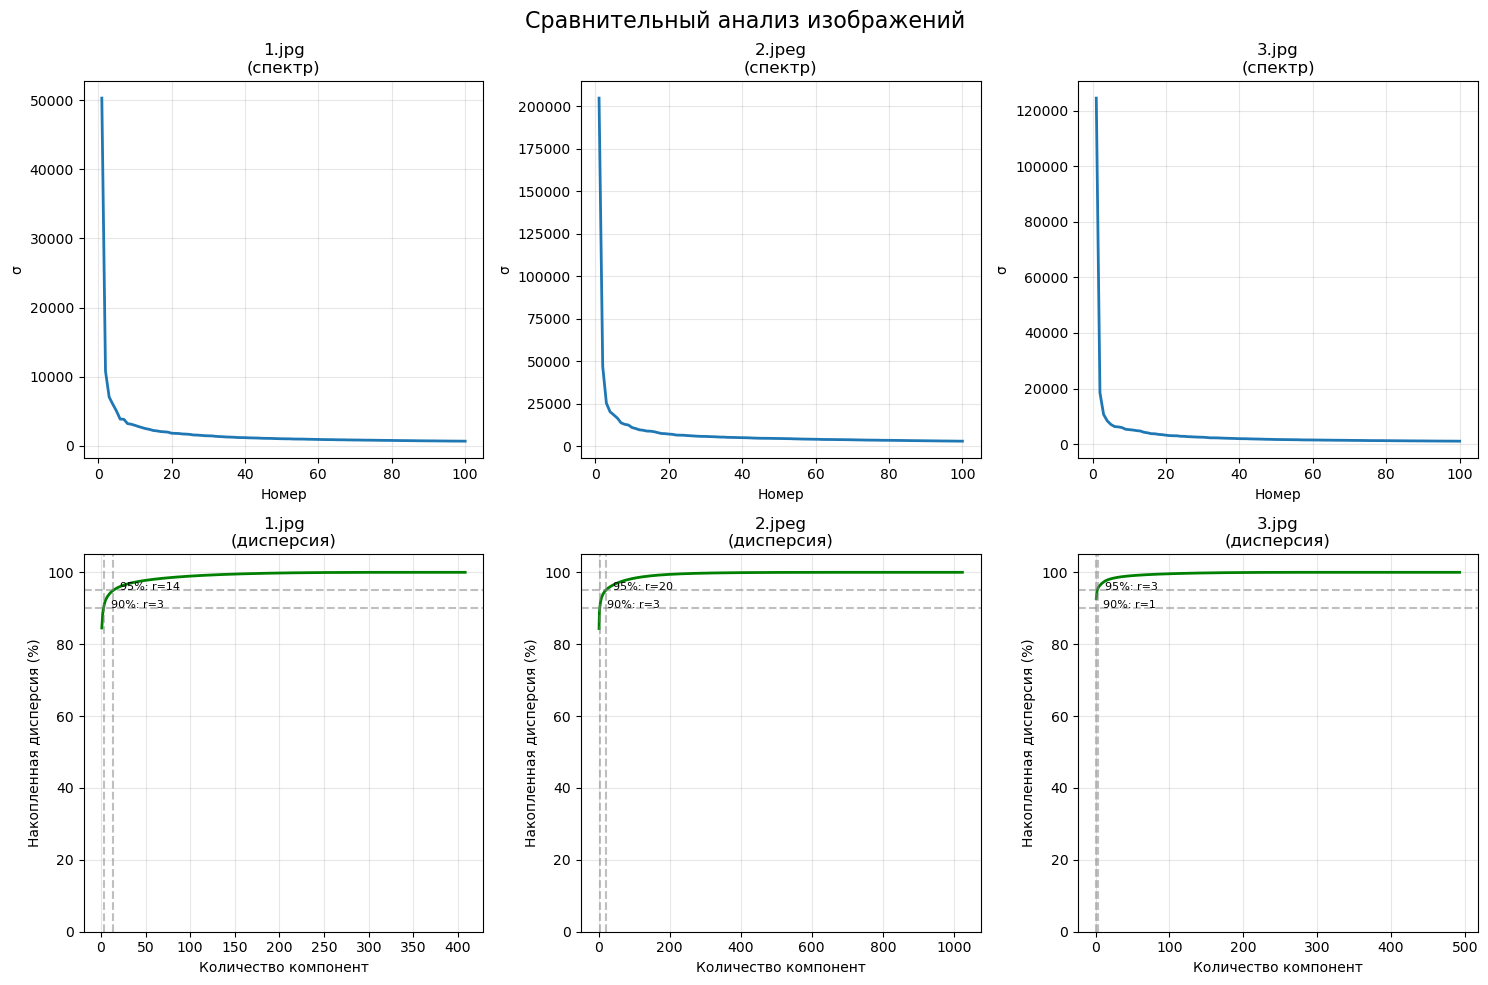


СВОДНАЯ ТАБЛИЦА
------------------------------------------------------------
Изображение     Размер          Ранг для 95%    Сжатие    
------------------------------------------------------------
1.jpg           612×408        14              17.5x
2.jpeg          1024×1024       20              25.6x
3.jpg           493×740        3               98.5x


In [19]:
print("\n" + "="*60)
print("СРАВНЕНИЕ ВСЕХ ИЗОБРАЖЕНИЙ")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (img, name) in enumerate(zip(images, image_names)):
    _, S, _ = np.linalg.svd(img, full_matrices=False)
    
    cumsum = np.cumsum(S**2) / np.sum(S**2) * 100
    
    ax = axes[0, idx]
    n_show = min(100, len(S))
    ax.plot(range(1, n_show+1), S[:n_show], linewidth=2)
    ax.set_title(f'{name}\n(спектр)')
    ax.set_xlabel('Номер')
    ax.set_ylabel('σ')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, idx]
    ax.plot(range(1, len(cumsum)+1), cumsum, 'g-', linewidth=2)
    
    for level in [90, 95]:
        r = np.argmax(cumsum >= level) + 1
        ax.axhline(y=level, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(x=r, color='gray', linestyle='--', alpha=0.5)
        ax.text(r, level, f'  {level}%: r={r}', fontsize=8)
    
    ax.set_title(f'{name}\n(дисперсия)')
    ax.set_xlabel('Количество компонент')
    ax.set_ylabel('Накопленная дисперсия (%)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 105)

plt.suptitle('Сравнительный анализ изображений', fontsize=16)
plt.tight_layout()
plt.show()

print("\nСВОДНАЯ ТАБЛИЦА")
print("-" * 60)
print(f"{'Изображение':<15} {'Размер':<15} {'Ранг для 95%':<15} {'Сжатие':<10}")
print("-" * 60)

for img, name in zip(images, image_names):
    _, S, _ = np.linalg.svd(img, full_matrices=False)
    cumsum = np.cumsum(S**2) / np.sum(S**2)
    rank_95 = np.argmax(cumsum >= 0.95) + 1
    compression = img.size / (rank_95 * (img.shape[0] + img.shape[1] + 1))
    print(f"{name:<15} {img.shape[0]}×{img.shape[1]:<10} {rank_95:<15} {compression:.1f}x")

ОБЪЯСНЕННАЯ ДИСПЕРСИЯ (Explained Variance) - это доля дисперсии (вариативности) 
исходных данных, которую сохраняет каждая компонента SVD.

МАТЕМАТИЧЕСКОЕ ОПРЕДЕЛЕНИЕ:
- Общая дисперсия = Σᵢⱼ (xᵢⱼ - mean)²
- Для SVD: общая дисперсия = Σᵢ σᵢ² (сумма квадратов сингулярных значений)
- Объясненная дисперсия для i-й компоненты = σᵢ² / Σⱼ σⱼ²

Каждая компонента SVD показывает направление, в котором точки наиболее разбросаны.
Если взять только первые k компонент, мы сохраним основную структуру данных,
отбросив "шум" (компоненты с малыми сингулярными значениями).

## Background detection using SVD

In [2]:
def load_video_to_matrix(video_path, max_frames=None, resize_shape=None):
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        raise ValueError(f"Не удалось открыть видео: {video_path}")
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Информация о видео:")
    print(f"  - Всего кадров: {total_frames}")
    print(f"  - FPS: {fps:.2f}")
    
    frames = []
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        if resize_shape is not None:
            frame = cv2.resize(frame, (resize_shape[1], resize_shape[0]))
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray.flatten())
        
        frame_count += 1
        if max_frames is not None and frame_count >= max_frames:
            break
    
    cap.release()
    
    height, width = gray.shape
    video_matrix = np.array(frames).T  # (height*width, n_frames)
    
    print(f"\nСоздана матрица размером: {video_matrix.shape}")
    print(f"  - Количество пикселей: {height * width}")
    print(f"  - Количество кадров: {video_matrix.shape[1]}")
    
    return video_matrix, height, width, fps

video_path = 'data/Video_008.avi'

if os.path.exists(video_path):
    video_matrix, height, width, fps = load_video_to_matrix(
        video_path, 
        max_frames=200, 
        resize_shape=(120, 160)
    )

print(f"\nМатрица видео: {video_matrix.shape}")
print(f"Количество пикселей: {video_matrix.shape[0]}")
print(f"Количество кадров: {video_matrix.shape[1]}")

Информация о видео:
  - Всего кадров: 793
  - FPS: 10.00

Создана матрица размером: (19200, 200)
  - Количество пикселей: 19200
  - Количество кадров: 200

Матрица видео: (19200, 200)
Количество пикселей: 19200
Количество кадров: 200


In [7]:
def decompose_video(video_matrix, rank=None):
    print("\nВыполнение SVD разложения...")
    U, S, Vt = svd(video_matrix, full_matrices=False)
    print(f"U: {U.shape}, S: {S.shape}, Vt: {Vt.shape}")
    
    if rank is not None:
        # Урезанное SVD
        U_k = U[:, :rank]
        S_k = np.diag(S[:rank])
        Vt_k = Vt[:rank, :]
        reconstructed = U_k @ S_k @ Vt_k
    else:
        reconstructed = U @ np.diag(S) @ Vt
    
    return U, S, Vt, reconstructed

U_full, S_full, Vt_full, _ = decompose_video(video_matrix)
print(f"\nСингулярные значения (первые 10):")
for i, val in enumerate(S_full[:10]):
    print(f"  σ_{i+1} = {val:.2f}")


Выполнение SVD разложения...
U: (19200, 200), S: (200,), Vt: (200, 200)

Сингулярные значения (первые 10):
  σ_1 = 248290.53
  σ_2 = 25343.68
  σ_3 = 5831.66
  σ_4 = 5341.10
  σ_5 = 4465.75
  σ_6 = 3895.42
  σ_7 = 3792.22
  σ_8 = 3545.90
  σ_9 = 3409.31
  σ_10 = 3191.01


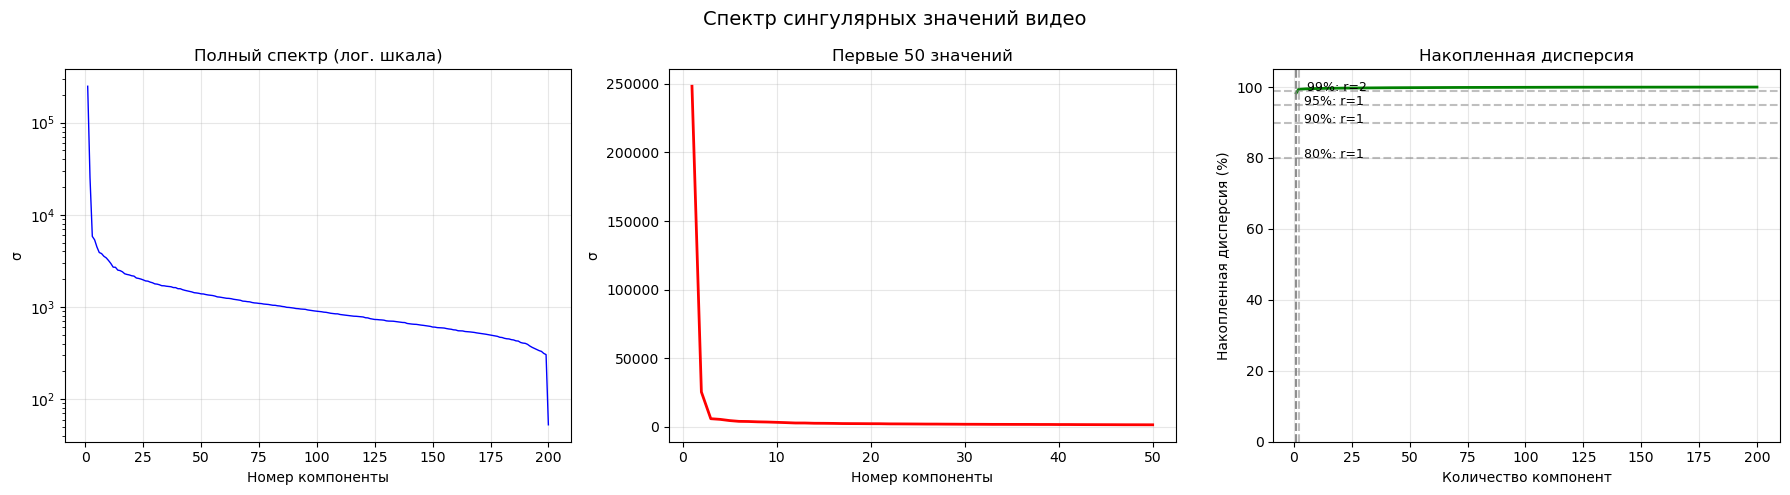


АНАЛИЗ СПЕКТРА:
Всего компонент: 200
  Для 80% дисперсии нужно 1 компонент
  Для 90% дисперсии нужно 1 компонент
  Для 95% дисперсии нужно 1 компонент
  Для 99% дисперсии нужно 2 компонент


In [8]:
def analyze_singular_values(S, title="Сингулярные значения"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    ax = axes[0]
    ax.plot(range(1, len(S)+1), S, 'b-', linewidth=1)
    ax.set_xlabel('Номер компоненты')
    ax.set_ylabel('σ')
    ax.set_title('Полный спектр (лог. шкала)')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    n_show = min(50, len(S))
    ax.plot(range(1, n_show+1), S[:n_show], 'r-', linewidth=2)
    ax.set_xlabel('Номер компоненты')
    ax.set_ylabel('σ')
    ax.set_title(f'Первые {n_show} значений')
    ax.grid(True, alpha=0.3)
    
    ax = axes[2]
    cumsum = np.cumsum(S**2) / np.sum(S**2) * 100
    ax.plot(range(1, len(cumsum)+1), cumsum, 'g-', linewidth=2)
    
    for level in [80, 90, 95, 99]:
        idx = np.argmax(cumsum >= level)
        if idx < len(cumsum):
            ax.axhline(y=level, color='gray', linestyle='--', alpha=0.5)
            ax.axvline(x=idx+1, color='gray', linestyle='--', alpha=0.5)
            ax.text(idx+1, level, f'  {level}%: r={idx+1}', fontsize=9)
    
    ax.set_xlabel('Количество компонент')
    ax.set_ylabel('Накопленная дисперсия (%)')
    ax.set_title('Накопленная дисперсия')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 105)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\nАНАЛИЗ СПЕКТРА:")
    print(f"Всего компонент: {len(S)}")
    for level in [80, 90, 95, 99]:
        idx = np.argmax(np.cumsum(S**2) / np.sum(S**2) >= level/100)
        print(f"  Для {level}% дисперсии нужно {idx+1} компонент")

analyze_singular_values(S_full, "Спектр сингулярных значений видео")

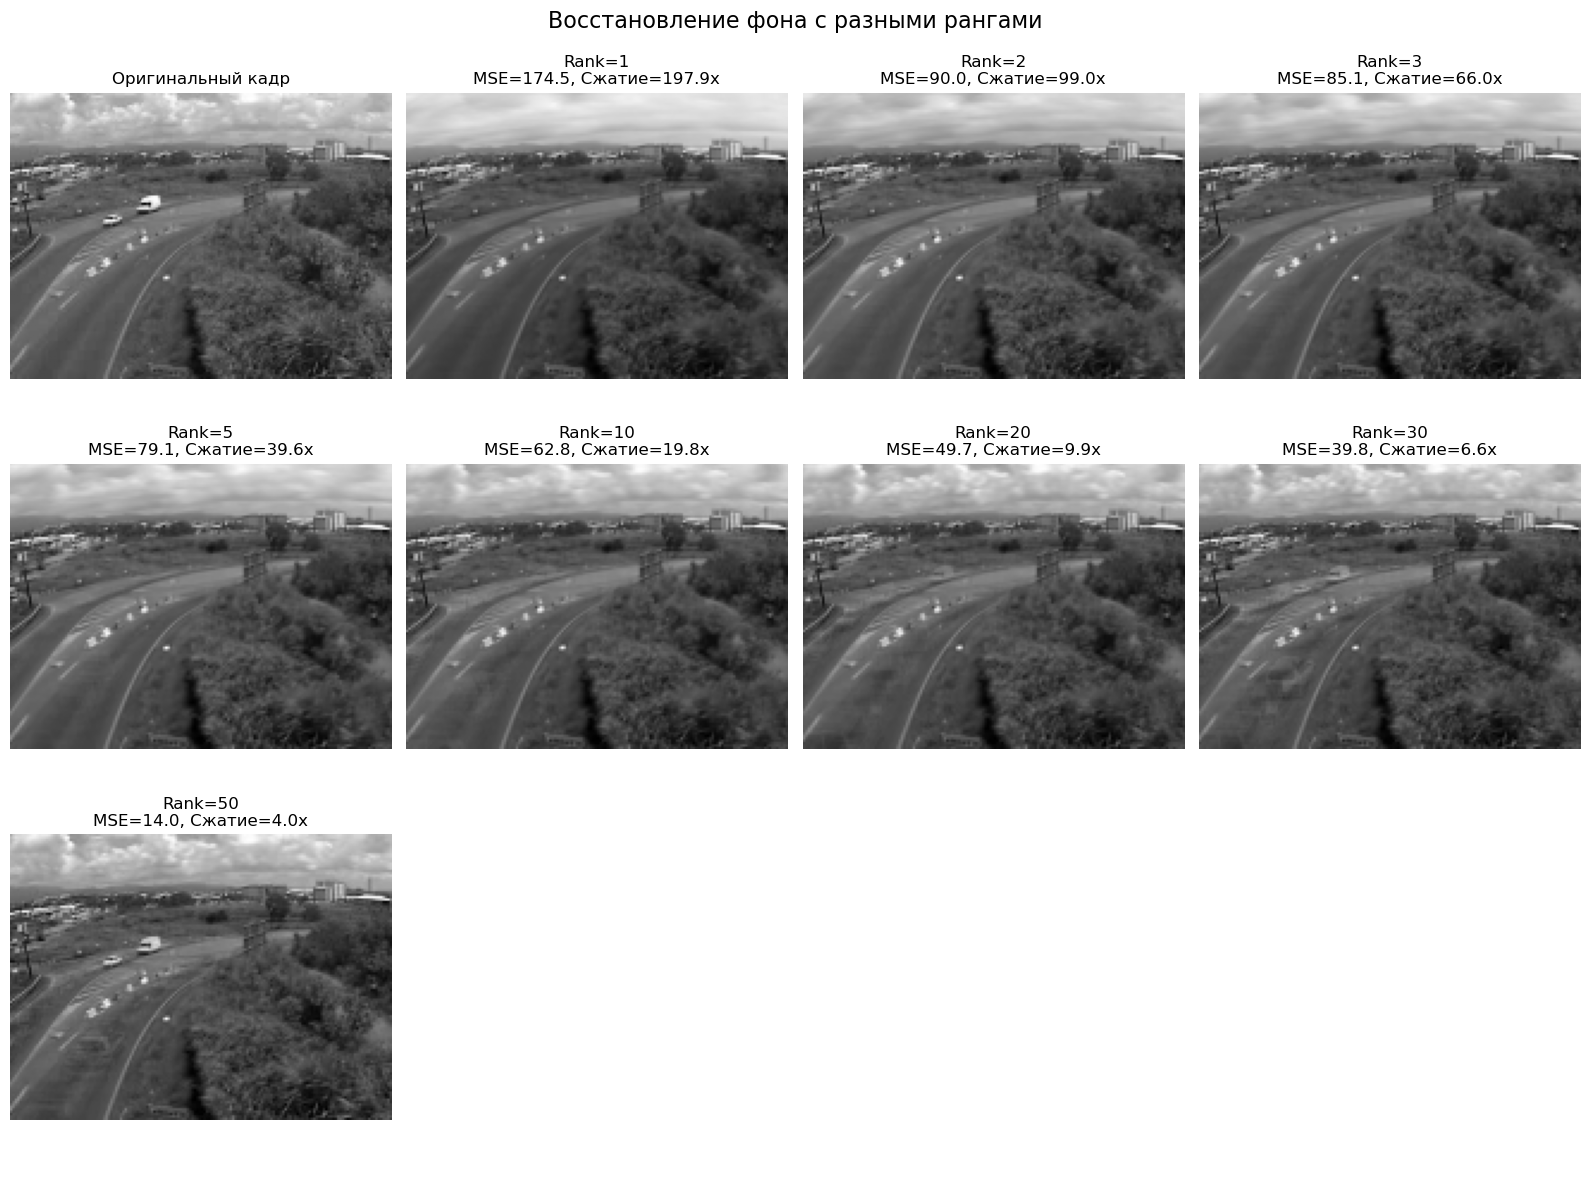

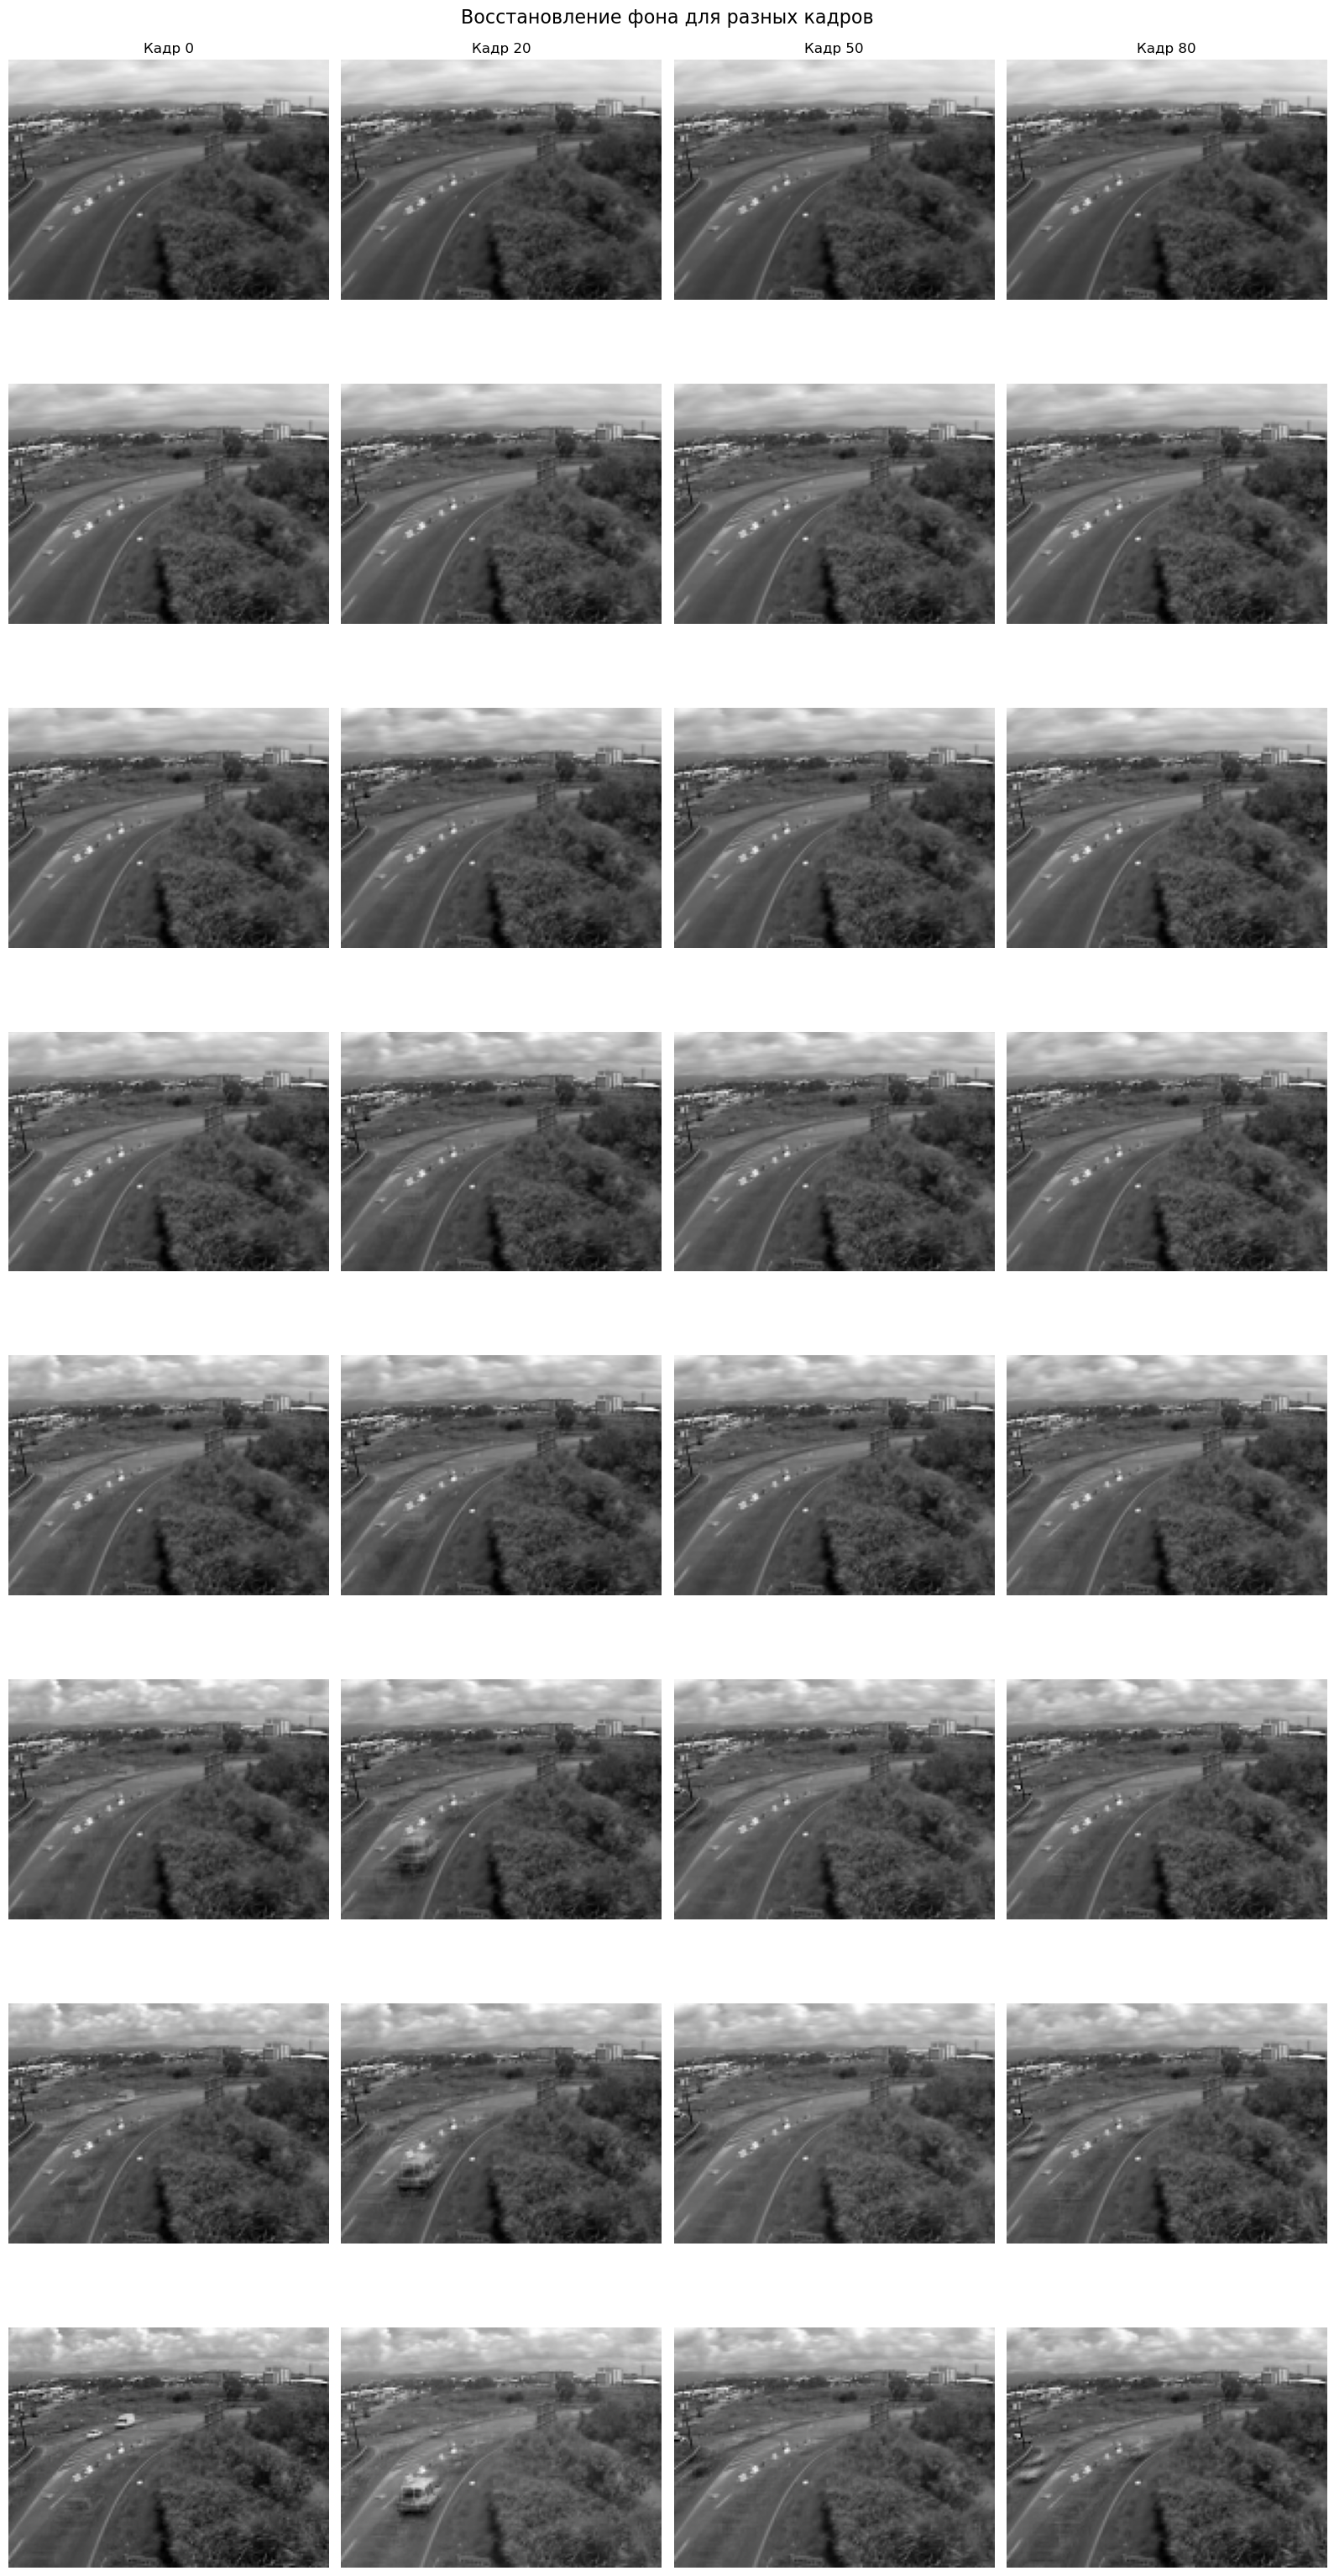

In [9]:
def reconstruct_frame(video_matrix, rank, frame_idx=0):
    U, S, Vt = svd(video_matrix, full_matrices=False)
    
    U_k = U[:, :rank]
    S_k = np.diag(S[:rank])
    Vt_k = Vt[:rank, :]
    
    reconstructed = U_k @ S_k @ Vt_k
    
    frame = reconstructed[:, frame_idx].reshape(height, width)
    
    frame = np.clip(frame, 0, 255)
    
    return frame

def visualize_background_reconstruction(video_matrix, height, width, ranks, frame_idx=0):
    original_frame = video_matrix[:, frame_idx].reshape(height, width)
    
    n_ranks = len(ranks)
    cols = 4
    rows = (n_ranks + cols - 1) // cols + 1  # +1 для оригинала
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.flatten()
    
    ax = axes[0]
    ax.imshow(original_frame, cmap='gray')
    ax.set_title('Оригинальный кадр')
    ax.axis('off')
    
    for idx, rank in enumerate(ranks):
        frame = reconstruct_frame(video_matrix, rank, frame_idx)
        ax = axes[idx + 1]
        ax.imshow(frame, cmap='gray')
        
        mse = np.mean((original_frame - frame) ** 2)
        compression_ratio = video_matrix.size / (rank * (video_matrix.shape[0] + video_matrix.shape[1] + 1))
        
        ax.set_title(f'Rank={rank}\nMSE={mse:.1f}, Сжатие={compression_ratio:.1f}x')
        ax.axis('off')
    
    for idx in range(n_ranks + 1, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Восстановление фона с разными рангами', fontsize=16)
    plt.tight_layout()
    plt.show()

ranks = [1, 2, 3, 5, 10, 20, 30, 50]

visualize_background_reconstruction(video_matrix, height, width, ranks, frame_idx=0)

fig, axes = plt.subplots(len(ranks), 4, figsize=(16, 4*len(ranks)))

for i, rank in enumerate(ranks):
    for j, frame_idx in enumerate([0, 20, 50, 80]):
        frame = reconstruct_frame(video_matrix, rank, frame_idx)
        ax = axes[i, j] if len(ranks) > 1 else axes[j]
        ax.imshow(frame, cmap='gray')
        if i == 0:
            ax.set_title(f'Кадр {frame_idx}')
        if j == 0:
            ax.set_ylabel(f'Rank={rank}')
        ax.axis('off')

plt.suptitle('Восстановление фона для разных кадров', fontsize=16)
plt.tight_layout()
plt.show()


Поиск оптимального ранга для восстановления фона...


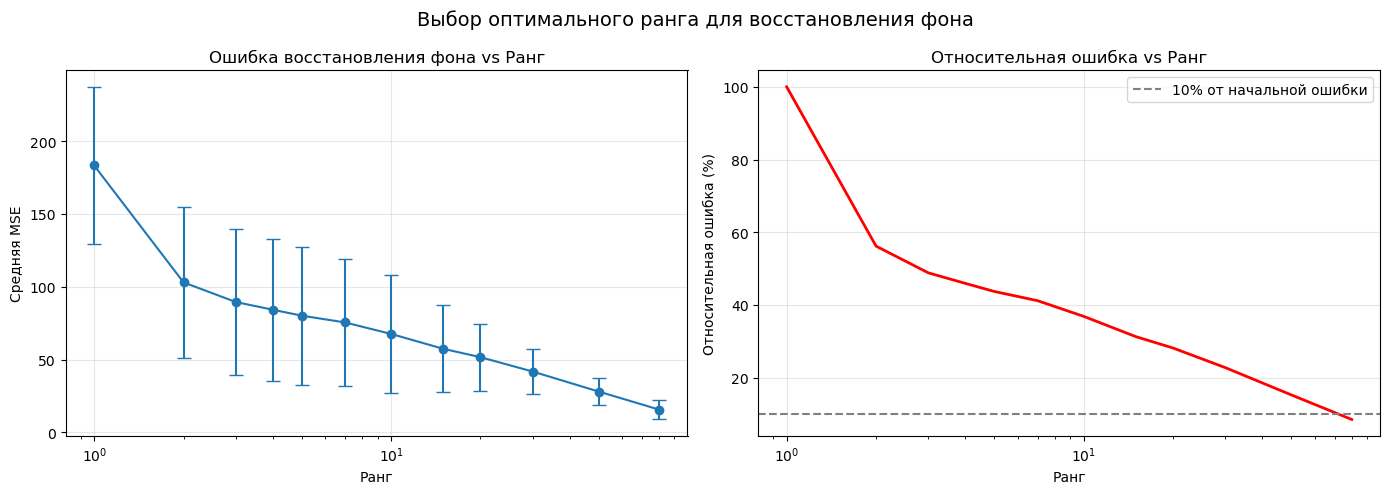


РЕЗУЛЬТАТЫ:
 rank   mean_mse   std_mse
    1 183.314514 54.041767
    2 103.007454 51.716431
    3  89.534523 49.957668
    4  84.206017 48.632843
    5  80.160645 47.423901
    7  75.495148 43.744160
   10  67.613617 40.388275
   15  57.364456 29.935511
   20  51.644577 22.939192
   30  41.758324 15.285421
   50  28.041817  9.055380
   80  15.606976  6.765654

Оптимальный ранг для фона: 80
При этом ранге средняя MSE: 15.61


In [15]:
def find_optimal_rank_for_background(video_matrix, test_ranks=None):
    if test_ranks is None:
        test_ranks = [1, 2, 3, 4, 5, 7, 10, 15, 20, 30, 50, 80]
    
    results = []
    
    for rank in test_ranks:
        frame_reconstructions = []
        errors = []
        
        for frame_idx in range(min(50, video_matrix.shape[1])):
            frame = reconstruct_frame(video_matrix, rank, frame_idx)
            original = video_matrix[:, frame_idx].reshape(height, width)
            
            mse = np.mean((original - frame) ** 2)
            errors.append(mse)
        
        results.append({
            'rank': rank,
            'mean_mse': np.mean(errors),
            'std_mse': np.std(errors)
        })
    
    return pd.DataFrame(results)

print("\nПоиск оптимального ранга для восстановления фона...")
results_df = find_optimal_rank_for_background(video_matrix)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.errorbar(results_df['rank'], results_df['mean_mse'], 
            yerr=results_df['std_mse'], fmt='o-', capsize=5)
ax.set_xlabel('Ранг')
ax.set_ylabel('Средняя MSE')
ax.set_title('Ошибка восстановления фона vs Ранг')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

ax = axes[1]
relative_error = results_df['mean_mse'] / results_df['mean_mse'].iloc[0] * 100
ax.plot(results_df['rank'], relative_error, 'r-', linewidth=2)
ax.axhline(y=10, color='gray', linestyle='--', label='10% от начальной ошибки')
ax.set_xlabel('Ранг')
ax.set_ylabel('Относительная ошибка (%)')
ax.set_title('Относительная ошибка vs Ранг')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xscale('log')

plt.suptitle('Выбор оптимального ранга для восстановления фона', fontsize=14)
plt.tight_layout()
plt.show()

print("\nРЕЗУЛЬТАТЫ:")
print(results_df.to_string(index=False))

# Находим rank, где ошибка стабилизируется
optimal_rank = results_df[results_df['mean_mse'] < results_df['mean_mse'].min() * 1.1]['rank'].min()
print(f"\nОптимальный ранг для фона: {optimal_rank}")
print(f"При этом ранге средняя MSE: {results_df[results_df['rank']==optimal_rank]['mean_mse'].values[0]:.2f}")

Выбрали порог не превышающий 110% от минимальной ошибки - баланс между сжатием и сохранением качества 